In [1]:
import awswrangler as wr
import boto3

# Confirma que a sessao carregou as credenciais certas
session = boto3.Session()
print("Region:", session.region_name)
print("Access Key:", session.get_credentials().access_key[:6] + "...")

Region: us-east-1
Access Key: AKIA36...


In [74]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Ve todos os databases (bronze/silver/gold)
wr.catalog.databases()

,Database,Description
0,bronze_layer_pipi,raw data
1,default,default database
2,gold_layer_pipo,business data
3,silver_layer_pipo,silter data wrangled


In [3]:
# Ve as tabelas dentro da Gold
wr.catalog.tables(database="gold_layer_pipo")

,Database,Table,Description,TableType,Columns,Partitions
0,gold_layer_pipo,dim_beneficiario,,EXTERNAL_TABLE,"sk_beneficiario, beneficiario_id, sexo, data_n...",
1,gold_layer_pipo,dim_corretor,,EXTERNAL_TABLE,"sk_corretor, corretor_id, corretor_nome, regia...",
2,gold_layer_pipo,dim_data,,EXTERNAL_TABLE,"sk_data, data, ano, mes, trimestre, ano_mes",
3,gold_layer_pipo,dim_empresa,,EXTERNAL_TABLE,"sk_empresa, empresa_id, empresa_nome, setor, p...",
4,gold_layer_pipo,dim_evento_saude,,EXTERNAL_TABLE,"sk_evento_saude, tipo_evento, especialidade, g...",
5,gold_layer_pipo,dim_plano,,EXTERNAL_TABLE,"sk_plano, plano_id, plano_nome, operadora_id, ...",
6,gold_layer_pipo,fct_contratos,,EXTERNAL_TABLE,"sk_data_venda, sk_vigencia_inicio, sk_vigencia...",
7,gold_layer_pipo,fct_mensal_contrato,,EXTERNAL_TABLE,"sk_mes_competencia, sk_empresa, sk_plano, sk_c...",
8,gold_layer_pipo,fct_utilizacao,,EXTERNAL_TABLE,"sk_data_evento, sk_beneficiario, sk_empresa, s...",


# Perguntas de Negócio e Análise

## 1. Planos mais vendidos nos últimos 12 meses (por nº de contratos e por vidas cobertas)

### Planos de Saúde Mais Vendidos — Principais Insights

A base analisada reúne 23 planos ativos de 8 operadoras distintas, somando 40 vendas registradas — média de 1,74 venda por plano, mas mediana de apenas 1. A distância entre média e mediana já denuncia uma distribuição concentrada, detalhada abaixo.

### Vendas concentradas em poucos planos

O plano mais vendido, FLEX 529 (Vitamed, ambulatorial), responde sozinho por 12,5% do volume total. Os três primeiros colocados — FLEX 529, CLASSICO 621 e MASTER 758 (estes dois últimos da Novaclin Intermedica) — somam 27,5% das vendas, e os cinco primeiros chegam a 40%. No outro extremo, 12 dos 23 planos (52%) venderam apenas uma unidade cada, representando juntos só 30% do volume: menos da metade do portfólio concentra dois terços das vendas.

### Vitamed é a operadora líder, com folga

Entre as 8 operadoras, a Vitamed lidera com 32,5% de participação (13 vendas em 5 planos), puxada pelo plano mais vendido do mercado. A Novaclin Intermedica vem em segundo, com 20% (8 vendas em 3 planos). Um pelotão intermediário — Plenacare, Aurora Saúde e Unicare Coop — empata em 10% cada, enquanto Sulvida Seguros e Sanare Saúde ficam em 7,5%. A Boavida Saúde fecha a lista com apenas 2,5% (1 plano, 1 venda).

### Ambulatorial puro é a segmentação mais vendida

Entre os quatro tipos de segmentação, Ambulatorial isolado lidera com 32,5% das vendas, seguido de Ambulatorial + Hospitalar (27,5%), Hospitalar isolado (22,5%) e, por último, Hospitalar + Obstetrícia (17,5%). Somando todos os planos combinados (com "+"), eles chegam a 45% do volume — relevante, mas ainda atrás da soma das duas segmentações puras (55%).

### Implicação

Com um portfólio fragmentado (23 planos, mediana de 1 venda) e vendas concentradas no topo, o caminho mais eficiente é reforçar os 5 planos que já respondem por 40% do volume — sobretudo os da Vitamed e Novaclin Intermedica — e revisar a relevância comercial dos 12 planos de venda única antes de seguir investindo neles igualmente.

*Fonte: planos_mais_vendidos.csv*


In [10]:
planos_mais_vendidos = wr.athena.read_sql_query(
    sql="""with table_cta as (
    select fc.contrato_id,
        dp.plano_nome,
        dp.operadora_nome,
        dp.segmentacao,
        dd.data
    from fct_contratos fc
    inner join dim_plano as dp on dp.plano_id = fc.sk_plano 
    inner join dim_data as dd on dd.sk_data = fc.sk_data_venda
    where dd.data BETWEEN
        date_add('month', -12, DATE '2025-06-30') + INTERVAL '1' DAY
            and DATE '2025-06-30'
        )
select 
    t.plano_nome,
    t.operadora_nome,
    t.segmentacao,
    count(distinct contrato_id) as total_planos
    from table_cta t
group by 1,2,3
order by 4 desc""",
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

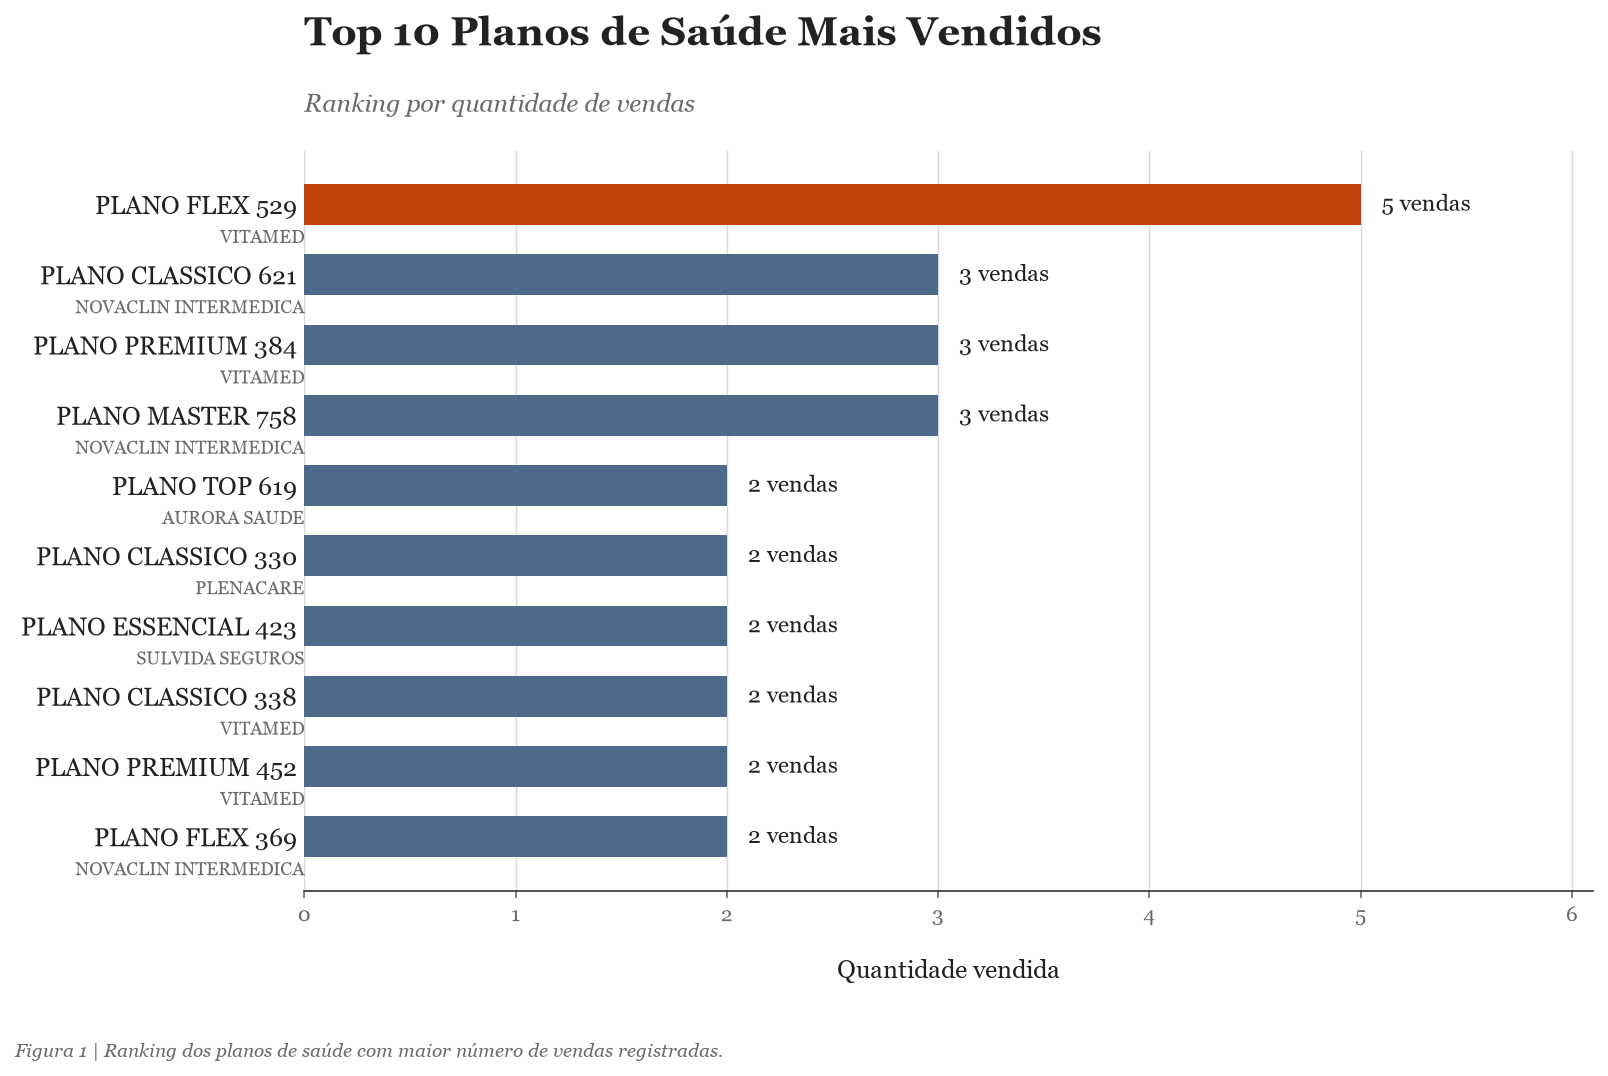

In [22]:
# ----------------------------------------------------------------------
# 1) Configurações
# ----------------------------------------------------------------------
CSV_PATH = "planos_mais_vendidos.csv"
TOP_N = 10  # quantidade de planos a exibir
 
COR_BASE = "#4C6B8A"       # azul acinzentado - paleta discreta de publicação
COR_DESTAQUE = "#C1440E"   # terracota para destacar o plano nº 1
COR_TEXTO = "#222222"
COR_CINZA = "#6B6B6B"
 
# ----------------------------------------------------------------------
# 2) Carregar e preparar os dados
# ----------------------------------------------------------------------
df = pd.read_csv(CSV_PATH, index_col=0)
 
df_top = df.sort_values("total_planos", ascending=False).head(TOP_N)
df_top = df_top.sort_values("total_planos", ascending=True).reset_index(drop=True)
 
valores = df_top["total_planos"].values
maximo = valores.max()
cores = [COR_DESTAQUE if v == maximo else COR_BASE for v in valores]
y_pos = range(len(df_top))
 
# ----------------------------------------------------------------------
# 3) Estilo "publicação científica"
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "axes.edgecolor": "#333333",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
 
fig, ax = plt.subplots(figsize=(11, 8.5), dpi=150)
bars = ax.barh(y_pos, valores, color=cores, height=0.58, zorder=3)
 
# Rótulo de valor ao final de cada barra
for bar, valor in zip(bars, valores):
    ax.text(
        bar.get_width() + maximo * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{valor} vendas",
        va="center", ha="left", fontsize=11, color=COR_TEXTO,
    )
 
# Rótulos do eixo Y em duas linhas: nome do plano (maior) + operadora (menor, cinza)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_top["plano_nome"], fontsize=12, color=COR_TEXTO)
for y, operadora in zip(y_pos, df_top["operadora_nome"]):
    ax.annotate(
        operadora,
        xy=(0, y), xycoords=("axes fraction", "data"),
        xytext=(0, -12), textcoords="offset points",
        ha="right", va="top", fontsize=8.5, color=COR_CINZA, annotation_clip=False,
    )
 
# ----------------------------------------------------------------------
# 4) Eixos e grid
# ----------------------------------------------------------------------
ax.set_xlim(0, maximo * 1.22)
ax.set_xlabel("Quantidade vendida", fontsize=12, color=COR_TEXTO, labelpad=16)
ax.tick_params(axis="x", labelsize=10, colors=COR_CINZA)
ax.tick_params(axis="y", length=0)
 
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#D9D9D9", linewidth=0.7, zorder=0)
ax.yaxis.grid(False)
 
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color("#333333")
 
# ----------------------------------------------------------------------
# 5) Título, subtítulo e legenda de figura
# ----------------------------------------------------------------------
ax.text(
    0, 1.13, f"Top {TOP_N} Planos de Saúde Mais Vendidos",
    transform=ax.transAxes, fontsize=19, fontweight="bold", color=COR_TEXTO,
    ha="left", va="bottom",
)
ax.text(
    0, 1.045, "Ranking por quantidade de vendas",
    transform=ax.transAxes, fontsize=12, style="italic", color=COR_CINZA,
    ha="left", va="bottom",
)
fig.text(
    0.03, 0.01,
    "Figura 1 | Ranking dos planos de saúde com maior número de vendas registradas.",
    fontsize=9, color=COR_CINZA, style="italic",
)
 
plt.tight_layout(rect=[0.02, 0.05, 1, 0.87])
plt.show()

## 2. Empresas com maior valor total contratado (prêmio mensal) nos últimos 6 meses.

### EMPRESA X24 LTDA com valor mensal nulo

# Insights — Faturamento Mensal por Empresa

**Base:** 27 empresas ativas (1 registro sem valor informado foi excluído) · Total mensal: **R\$ 8.706.024**

### 1. Concentração de receita

- As **5 maiores contas** respondem por **41%** do faturamento total; as **10 maiores**, por **66%**.
- A maior empresa isolada (Q17, Logística) já representa **12,6%** do total sozinha.
- As 10 empresas menores somam apenas **13,4%** do total — a base é fortemente assimétrica (mediana de R\$ 228 mil vs. média de R\$ 322 mil).
- Razão entre maior e menor valor: **65x** (R\$ 1,09 mi vs. R\$ 16,8 mil).

### 2. Por porte

| Porte | Empresas | Faturamento | % do total | Média/empresa |
|---|---|---|---|---|
| Grande | 10 | R\$ 4,38 mi | **50%** | R\$ 438 mil |
| Pequena | 11 | R\$ 2,69 mi | 31% | R\$ 245 mil |
| Média | 6 | R\$ 1,63 mi | 19% | R\$ 272 mil |

Empresas **Grandes** são só 37% da base em quantidade, mas geram metade da receita — consistente com a concentração observada acima.

### 3. Por setor

| Setor | Empresas | Faturamento | % do total |
|---|---|---|---|
| Saúde | 6 | R\$ 1,92 mi | 22% |
| Logística | 3 | R\$ 1,73 mi | 20% |
| Educação | 6 | R\$ 1,50 mi | 17% |
| Agronegócio | 4 | R\$ 1,04 mi | 12% |
| Serviços Financeiros | 2 | R\$ 887 mil | 10% |
| Tecnologia | 2 | R\$ 670 mil | 8% |
| Indústria | 2 | R\$ 630 mil | 7% |
| Varejo | 2 | R\$ 328 mil | 4% |

- **Saúde** lidera em faturamento total, mas por **volume** (6 empresas, quase todas pequenas) — não por ticket médio.
- **Logística** é o oposto: só 3 empresas, mas o maior ticket médio do estudo (R\$ 576 mil/empresa) e concentra 2 das contas Grandes, incluindo a maior de toda a base.
- **Varejo** é o setor menos relevante, tanto em número de empresas quanto em receita (4%).

### 4. Ponto de atenção (outlier)

A **EMPRESA K37 LTDA** (Agronegócio) está classificada como porte **Grande**, mas tem o **menor valor mensal de toda a base** (R\$ 16.782 — muito abaixo até das menores empresas Pequenas). Vale validar se há erro de classificação de porte ou algum evento atípico (ex.: mês de entrada/saída, dado incompleto) para essa empresa.

---
*Gráfico correspondente: `ranking_faturamento_empresas.png`*



In [23]:
contratos_por_empresa = wr.athena.read_sql_query(
    sql="""with cta as (
    select 
        fc.sk_empresa,
        de.empresa_nome,
        de.setor,
        de.porte, 
        dd.data data_venda,
        fc.valor_mensal
    from fct_contratos fc
    inner join dim_data as dd on dd.sk_data = fc.sk_data_venda
    inner join dim_empresa de on de.sk_empresa = fc.sk_empresa
    where dd.data between
        date_add('month', -12, DATE '2025-06-30') + INTERVAL '1' DAY
            and DATE '2025-06-30'
        )
    
        
 select 
    c.empresa_nome,
    c.setor,
    c.porte,
    sum(c.valor_mensal) valor_mensal_por_empresa
 from cta c    
group by 1,2,3 
order by 4 desc nulls last
        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

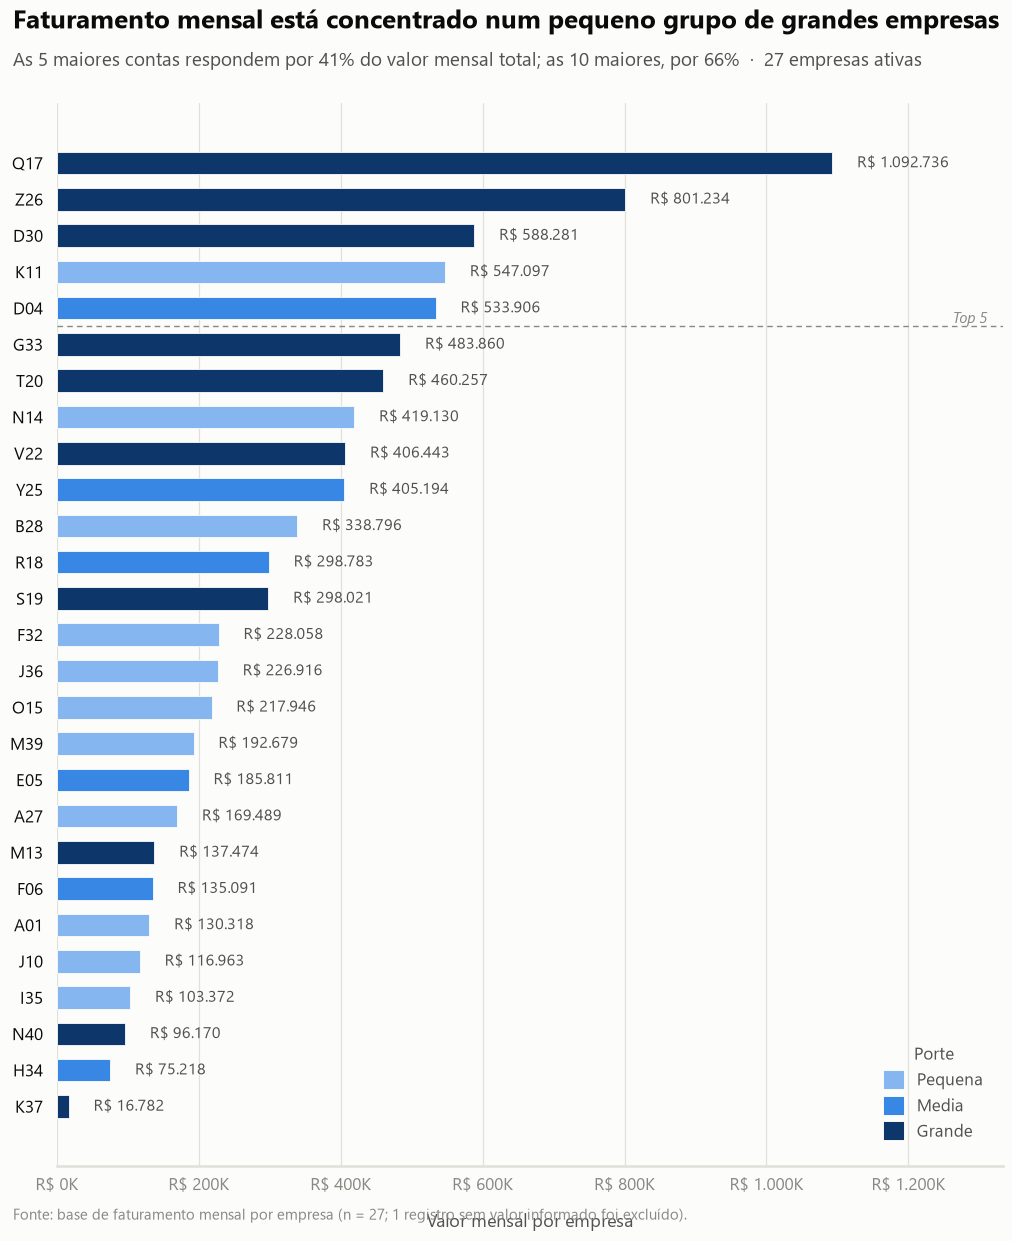

In [94]:


# ----------------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------------


df = contratos_por_empresa.dropna(subset=["valor_mensal_por_empresa"]).copy()
df = df.dropna(subset=["valor_mensal_por_empresa"]).copy()
df["valor_mensal_por_empresa"] = pd.to_numeric(
    df["valor_mensal_por_empresa"], errors="coerce"
).astype("float64")
df["codigo"] = df["empresa_nome"].str.extract(r"EMPRESA\s+(\w+)\s+LTDA")
df = df.sort_values("valor_mensal_por_empresa", ascending=True).reset_index(drop=True)

total = df["valor_mensal_por_empresa"].sum()
top5_share = df.sort_values("valor_mensal_por_empresa", ascending=False)["valor_mensal_por_empresa"].head(5).sum() / total * 100
top10_share = df.sort_values("valor_mensal_por_empresa", ascending=False)["valor_mensal_por_empresa"].head(10).sum() / total * 100

# ----------------------------------------------------------------------------
# Palette — ordinal blue ramp (dataviz skill: references/palette.md)
# PEQUENA -> step 250, MEDIA -> step 400, GRANDE -> step 700
# ----------------------------------------------------------------------------
PORTE_ORDER = ["PEQUENA", "MEDIA", "GRANDE"]
PORTE_COLOR = {
    "PEQUENA": "#86b6ef",
    "MEDIA":   "#3987e5",
    "GRANDE":  "#0d366b",
}
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "axes.edgecolor": GRIDLINE,
    "text.color": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

fig, ax = plt.subplots(figsize=(11, 12.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

colors = df["porte"].map(PORTE_COLOR)
bars = ax.barh(
    df["codigo"], df["valor_mensal_por_empresa"],
    color=colors, height=0.62, zorder=3,
    edgecolor=SURFACE, linewidth=0.6,
)

# Value labels at bar ends
for bar, val in zip(bars, df["valor_mensal_por_empresa"]):
    ax.text(
        bar.get_width() + total * 0.004, bar.get_y() + bar.get_height() / 2,
        f"R$ {val:,.0f}".replace(",", "."),
        va="center", ha="left", fontsize=11.5, color=INK_SECONDARY,
    )

# Gridlines behind bars only, vertical
ax.grid(axis="x", color=GRIDLINE, linewidth=0.9, zorder=0)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)

ax.set_xlim(0, df["valor_mensal_por_empresa"].max() * 1.22)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1000:,.0f}K".replace(",", "."))
)
ax.tick_params(axis="x", labelsize=12, length=0, pad=8)
ax.tick_params(axis="y", labelsize=12.5, length=0, pad=10)
ax.set_xlabel("Valor mensal por empresa", fontsize=13, color=INK_SECONDARY, labelpad=14)
ax.set_ylabel("")

# Title block — headline communicates the story, not the mechanics
fig.text(
    0.06, 0.965,
    "Faturamento mensal está concentrado num pequeno grupo de grandes empresas",
    fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left",
)
fig.text(
    0.06, 0.935,
    f"As 5 maiores contas respondem por {top5_share:.0f}% do valor mensal total; as 10 maiores, por {top10_share:.0f}%  ·  27 empresas ativas",
    fontsize=13.5, color=INK_SECONDARY, ha="left",
)

# Legend for porte (categorical identity, ordinal order preserved)
handles = [plt.Rectangle((0, 0), 1, 1, color=PORTE_COLOR[p]) for p in PORTE_ORDER]
legend = ax.legend(
    handles, [p.title() for p in PORTE_ORDER],
    title="Porte", loc="lower right", bbox_to_anchor=(0.995, 0.01),
    frameon=False, fontsize=12, title_fontsize=12.5,
    handlelength=1.1, handleheight=1.1,
)
legend.get_title().set_color(INK_SECONDARY)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

# Reference line marking the top-5 cut
ax.axhline(len(df) - 5.5, color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.text(
    df["valor_mensal_por_empresa"].max() * 1.20, len(df) - 5.5,
    "Top 5",
    fontsize=11, color=INK_MUTED, ha="right", va="bottom", style="italic",
)

fig.text(
    0.06, 0.012,
    "Fonte: base de faturamento mensal por empresa (n = 27; 1 registro sem valor informado foi excluído).",
    fontsize=10.5, color=INK_MUTED, ha="left",
)

plt.subplots_adjust(left=0.10, right=0.96, top=0.905, bottom=0.055)

plt.savefig(
    r"C:\Users\gnose\Downloads\faturamento_mensal_empresas.png",
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)


## Performance dos corretores no último trimestre: valor total vendido, nº de contratos e vidas — normalizado de uma forma que você considere justa para comparar corretores


### Performance dos Corretores — Insights e Critérios

**Base:** 23 corretores · 57 contratos · vigências entre 2024 e 2026
**Totais brutos:** R\$ 12,0 mi em valor mensal · 21.216 vidas · 57 contratos
*(1 contrato sem valor informado foi excluído apenas das somas de valor.)*

---

### Critério de normalização (como a comparação foi feita "justa")

O problema central: **corretores têm tempos de casa muito diferentes** — de **1,3 ano** (Igor Oliveira, 15 meses) a **6,4 anos** (Tiago Nunes, 77 meses). Comparar valor vendido, contratos ou vidas de forma bruta favorece automaticamente quem está há mais tempo na empresa, porque teve mais tempo para acumular.

Para corrigir isso, cada uma das 3 métricas foi dividida pelo **tempo de casa em anos**, virando uma **taxa de produtividade anual**:

| Métrica bruta | Métrica normalizada |
|---|---|
| Valor total vendido | Valor vendido **por ano de casa** |
| Nº de contratos | Contratos **por ano de casa** |
| Total de vidas | Vidas **por ano de casa** |

O **Índice de Performance (0–100)** é a **média do percentil** de cada corretor nessas 3 taxas.

**Por que percentil e não min-max?** Um único corretor com taxa muito acima da média (Igor Oliveira) comprimiria toda a escala num min-max simples, achatando as diferenças entre os demais. O percentil (ranking relativo) é robusto a esses outliers e trata as 3 dimensões com peso igual.

**Efeito da normalização (validação do critério):**
- Correlação tempo de casa × valor vendido bruto: **+0,12** (praticamente nula — mais tempo não garante mais venda).
- Correlação tempo de casa × valor vendido *por ano*: **−0,58** (negativa — os mais novos produzem mais por ano).

Isso confirma que **sem normalizar, o ranking mediria antiguidade, não performance.**

---

### Ranking — Top 6 e Bottom 4

| # | Corretor | Senioridade | Meses de casa | Valor total | Contratos | Vidas | Índice |
|---|---|---|---|---|---|---|---|
| 1 | Igor Oliveira | Junior | 15 | R\$ 724 mil | 4 | 1.239 | **100** |
| 2 | Paulo Santos | Junior | 19 | R\$ 427 mil | 3 | 740 | 93 |
| 3 | Bruno Silva | Senior | 38 | R\$ 816 mil | 3 | 1.611 | 90 |
| 4 | Xuxa Silva | Junior | 32 | R\$ 578 mil | 3 | 1.092 | 86 |
| 5 | Xuxa Nunes | Junior | 33 | R\$ 1,06 mi | 2 | 1.170 | 86 |
| 6 | Karina Souza | Junior | 61 | R\$ 988 mil | 4 | 1.625 | 78 |
| … | | | | | | | |
| 20 | Ursula Pereira | Junior | 47 | R\$ 137 mil | 2 | 422 | 20 |
| 21 | Rafael Silva | Junior | 71 | R\$ 369 mil | 2 | 485 | 16 |
| 22 | Gabriel Silva | Junior | 38 | R\$ 130 mil | 1 | 430 | 15 |
| 23 | Tiago Rocha | Senior | 71 | R\$ 339 mil | 1 | 647 | 13 |

---

### Principais insights

1. **Ao normalizar pelo tempo de casa, os júnior lideram.** Índice médio por senioridade: **Júnior 57 · Pleno 46 · Sênior 44**. O topo do ranking é dominado por corretores com menos de 3 anos de empresa (Igor, Paulo, Xuxa Silva).

2. **Antiguidade ≠ performance.** Os corretores mais antigos (Tiago Rocha, Rafael Silva, Tiago Nunes — todos 71+ meses) aparecem no fim do ranking normalizado. Fecham poucos contratos por ano relativo ao tempo que têm de casa.

3. **O líder bruto de valor não é o líder de performance.** Carla Rocha é quem mais vendeu em valor absoluto (R\$ 1,14 mi), mas como está há 6 anos na casa, cai para o meio da tabela (índice 71) quando ajustado por tempo. Igor Oliveira vendeu menos em absoluto (R\$ 724 mil), mas em apenas 1,3 ano — a maior taxa anual da base.

4. **Bruno Silva é a exceção sênior.** Único não-júnior no top 5: sustenta alto volume de vidas (1.611) e valor mesmo com 38 meses de casa — perfil sólido e consistente nas 3 dimensões.

5. **Cancelamentos são pontuais.** Apenas 4 dos 57 contratos foram cancelados (7%), distribuídos entre Paulo Santos, Karina Souza, Diego Oliveira e Tiago Nunes — 1 cada. Não há corretor com padrão preocupante de cancelamento.

---

### Ressalvas metodológicas

- A base parece um **recorte de contratos com vigência recente (2024–2026)**, não o histórico completo de carreira. Corretores antigos podem ter fechado contratos anteriores fora da amostra, o que **subestima** sua taxa "por ano de casa". O índice reflete, portanto, **produtividade recente relativa ao tempo de empresa** — não a carreira inteira.
- "Valor vendido" soma o `valor_mensal` de todos os contratos independente do status atual (ativo, renovado ou cancelado), medindo capacidade de originação. Se o objetivo for receita *retida*, contratos cancelados deveriam ser descontados — o que penalizaria os 4 corretores da nota 5.

---
*Gráfico correspondente: `performance_corretores.png` · Script: `plot_corretores.py`*


In [31]:
valor_corretores = wr.athena.read_sql_query(
    sql="""select 
    fc.sk_corretor,
    dc.corretor_nome,
    dc.senioridade,
    dc.data_admissao,
    dc.meses_de_casa,
    dd.data as data_vigencia_inicio,
    dd1.data as data_vigencia_fim,
    fc.valor_mensal,
    fc.num_vidas,
    fc.ticket_por_vida,
    fc.status,
    fc.valor_mensal*3 as valor_trimestral
    
from fct_contratos fc
inner join (select t.data, t.sk_data from dim_data t) as dd on dd.sk_data = fc.sk_vigencia_inicio
inner join (select t.data, t.sk_data  from dim_data t) as dd1 on dd1.sk_data = fc.sk_vigencia_fim
inner join dim_corretor dc on fc.sk_corretor = dc.sk_corretor
where 
    dd.data <= DATE '2025-06-30'
    and dd1.data    >= DATE '2025-04-01'
        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

Text(0.06, 0.045, 'Fonte: contratos por corretor (n = 23 corretores, 57 contratos, período de vigência 2024–2026).\n"Valor vendido" soma valor_mensal de todos os contratos, independente do status atual (ativo, renovado ou cancelado); 1 contrato sem valor informado foi excluído apenas da soma de valor.')

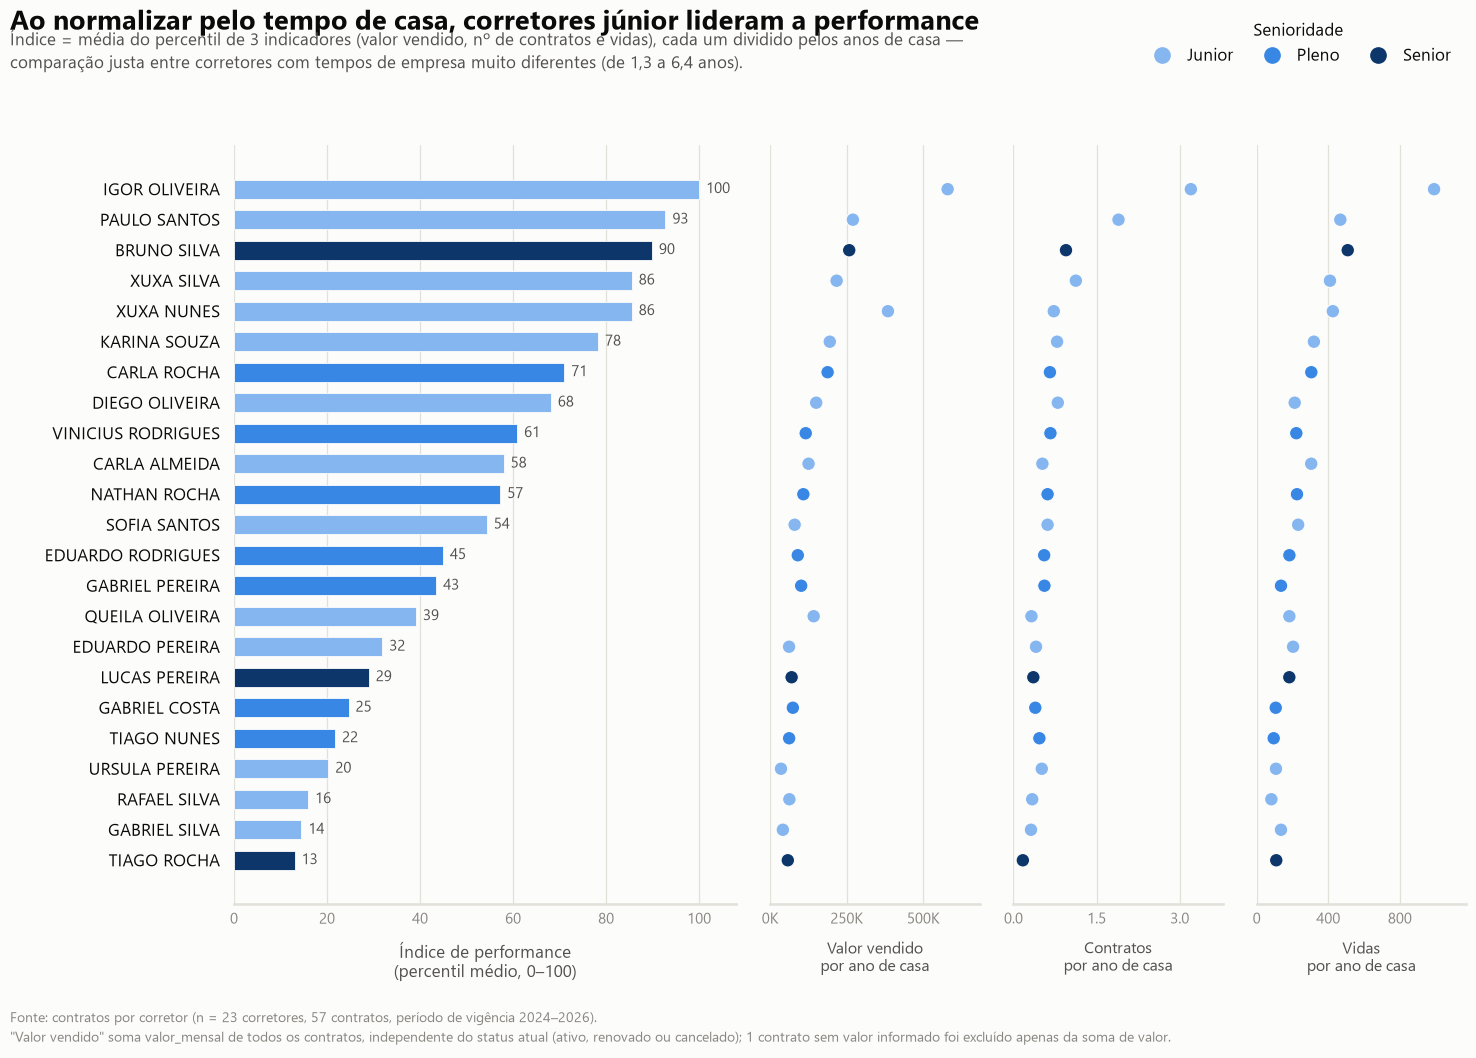

In [36]:


df = valor_corretores
df["valor_mensal"] = pd.to_numeric(df["valor_mensal"], errors="coerce")
df["num_vidas"] = pd.to_numeric(df["num_vidas"], errors="coerce")

# Cada linha é um contrato; um mesmo corretor aparece em várias linhas.
# Atributos de corretor (senioridade, meses_de_casa) são constantes por sk_corretor.
agg = (
    df.groupby(["sk_corretor", "corretor_nome", "senioridade", "meses_de_casa"])
    .agg(
        valor_total=("valor_mensal", "sum"),
        contratos=("valor_mensal", "size"),
        vidas_total=("num_vidas", "sum"),
        cancelados=("status", lambda s: (s == "CANCELADO").sum()),
    )
    .reset_index()
)

# --- Normalização "justa": cada métrica bruta é dividida pelo tempo de casa
# (anos), para não favorecer corretores só por estarem há mais tempo na
# empresa. O Índice de Performance é a média do percentil (0-100) das 3 taxas
# resultantes — robusto a outliers, ao contrário de um min-max simples.
agg["anos_de_casa"] = agg["meses_de_casa"] / 12
agg["rate_valor"] = agg["valor_total"] / agg["anos_de_casa"]
agg["rate_contratos"] = agg["contratos"] / agg["anos_de_casa"]
agg["rate_vidas"] = agg["vidas_total"] / agg["anos_de_casa"]


def pct_rank(s):
    return s.rank(method="average", pct=True) * 100


agg["idx"] = (
    pct_rank(agg["rate_valor"]) + pct_rank(agg["rate_contratos"]) + pct_rank(agg["rate_vidas"])
) / 3

agg = agg.sort_values("idx", ascending=True).reset_index(drop=True)

# ----------------------------------------------------------------------------
# Paleta — rampa ordinal de azul por senioridade (dataviz skill: palette.md)
# ----------------------------------------------------------------------------
SENIOR_ORDER = ["JUNIOR", "PLENO", "SENIOR"]
SENIOR_COLOR = {
    "JUNIOR": "#86b6ef",
    "PLENO":  "#3987e5",
    "SENIOR": "#0d366b",
}
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "axes.edgecolor": GRIDLINE,
    "text.color": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

colors = agg["senioridade"].map(SENIOR_COLOR)
n = len(agg)

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor(SURFACE)
gs = gridspec.GridSpec(
    1, 4, width_ratios=[2.4, 1, 1, 1], wspace=0.12,
    left=0.20, right=0.97, top=0.86, bottom=0.17,
)

# ---- Painel principal: Índice de Performance Ajustado (0-100) --------------
ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor(SURFACE)
ax0.barh(agg["corretor_nome"], agg["idx"], color=colors, height=0.62, zorder=3,
         edgecolor=SURFACE, linewidth=0.6)
for y, val in enumerate(agg["idx"]):
    ax0.text(val + 1.5, y, f"{val:.0f}", va="center", ha="left",
             fontsize=11, color=INK_SECONDARY)
ax0.set_xlim(0, 108)
ax0.grid(axis="x", color=GRIDLINE, linewidth=0.9, zorder=0)
ax0.grid(axis="y", visible=False)
ax0.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax0.spines[spine].set_visible(False)
ax0.spines["bottom"].set_color(GRIDLINE)
ax0.tick_params(axis="x", labelsize=11, length=0, pad=6)
ax0.tick_params(axis="y", labelsize=12, length=0, pad=10)
ax0.set_xlabel("Índice de performance\n(percentil médio, 0–100)", fontsize=12,
               color=INK_SECONDARY, labelpad=10)

# ---- Painéis secundários: as 3 taxas normalizadas que compõem o índice -----
panels = [
    ("rate_valor", "Valor vendido\npor ano de casa",
     lambda x, _: f"{x/1000:,.0f}K".replace(",", ".")),
    ("rate_contratos", "Contratos\npor ano de casa",
     lambda x, _: f"{x:,.1f}".replace(",", ".")),
    ("rate_vidas", "Vidas\npor ano de casa",
     lambda x, _: f"{x:,.0f}".replace(",", ".")),
]

for i, (col, label, fmt) in enumerate(panels):
    ax = fig.add_subplot(gs[i + 1], sharey=ax0)
    ax.set_facecolor(SURFACE)
    ax.scatter(agg[col], agg["corretor_nome"], color=colors, s=95, zorder=3,
               edgecolor=SURFACE, linewidth=0.8)
    ax.set_xlim(0, agg[col].max() * 1.18)
    ax.grid(axis="x", color=GRIDLINE, linewidth=0.9, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.tick_params(axis="x", labelsize=10.5, length=0, pad=6)
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis="y", length=0)
    ax.set_xlabel(label, fontsize=11.5, color=INK_SECONDARY, labelpad=10)

# ---- Título / storytelling --------------------------------------------------
fig.text(
    0.06, 0.965,
    "Ao normalizar pelo tempo de casa, corretores júnior lideram a performance",
    fontsize=19.5, fontweight="bold", color=INK_PRIMARY, ha="left",
)
fig.text(
    0.06, 0.930,
    "Índice = média do percentil de 3 indicadores (valor vendido, nº de contratos e vidas), cada um dividido pelos anos de casa —\n"
    "comparação justa entre corretores com tempos de empresa muito diferentes (de 1,3 a 6,4 anos).",
    fontsize=12.5, color=INK_SECONDARY, ha="left", linespacing=1.5,
)

# Legenda de senioridade
handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=11,
                       markerfacecolor=SENIOR_COLOR[s], markeredgecolor=SENIOR_COLOR[s])
           for s in SENIOR_ORDER]
fig.legend(
    handles, [s.title() for s in SENIOR_ORDER], title="Senioridade",
    loc="upper right", bbox_to_anchor=(0.97, 0.985), ncol=3,
    frameon=False, fontsize=12, title_fontsize=12.5,
    handletextpad=0.5, columnspacing=1.3,
)

fig.text(
    0.06, 0.045,
    "Fonte: contratos por corretor (n = 23 corretores, 57 contratos, período de vigência 2024–2026).\n"
    "\"Valor vendido\" soma valor_mensal de todos os contratos, independente do status atual (ativo, renovado ou cancelado); "
    "1 contrato sem valor informado foi excluído apenas da soma de valor.",
    fontsize=10, color=INK_MUTED, ha="left", linespacing=1.5,
)




## Contratos a expirar nos próximos 30 dias, com o valor em risco de cada um.

### Contratos a Expirar em 30 Dias — Valor em Risco

**Base:** 4 contratos com vigência a vencer nos próximos 30 dias
**Exposição total:** R\$ 338.800/mês · **961 vidas** · equivalente trimestral R\$ 1.016.400

---

### Valor em risco por contrato

| Corretor | Senioridade | Fim da vigência | Valor mensal em risco | Vidas | Status |
|---|---|---|---|---|---|
| Paulo Santos | Junior | 02/06 | R\$ 165.816 | 284 | 🔴 Cancelado |
| Xuxa Silva | Junior | 18/06 | R\$ 132.286 | 548 | 🟢 Renovado |
| Eduardo Rodrigues | Pleno | 24/06 | R\$ 24.152 | 107 | 🟢 Renovado |
| Diego Oliveira | Junior | 19/06 | R\$ 16.545 | 22 | 🔴 Cancelado |

---

### Principais insights

1. **Mais da metade da exposição já virou perda.** Dos R\$ 338.800/mês a expirar, **R\$ 182.361/mês (54%) estão em 2 contratos já cancelados** (Paulo Santos e Diego Oliveira). Os outros R\$ 156.439/mês (46%) foram renovados e estão retidos.

2. **A maior conta é a que se perdeu.** O contrato de maior valor de toda a base — **Paulo Santos, R\$ 165.816/mês (284 vidas)** — foi cancelado. Sozinho, representa 49% de todo o valor a expirar e 91% do valor perdido.

3. **A maior carteira de vidas foi salva.** O contrato de **Xuxa Silva concentra 548 vidas** (57% das 961 em risco) e foi renovado — a maior retenção em número de beneficiários.

4. **Concentração de risco.** Apenas 2 contratos (Paulo Santos + Xuxa Silva) somam **88% de todo o valor mensal** a expirar; os outros 2 são de baixo valor unitário (R\$ 16–24 mil/mês).

5. **Cancelamento não segue o tamanho.** Os cancelados incluem tanto o maior contrato (Paulo Santos) quanto o menor (Diego Oliveira, R\$ 16.545). Não há relação clara entre valor do contrato e desfecho nesta amostra pequena.

---

### Como o "valor em risco" foi definido

- **Valor em risco = `valor_mensal`** de cada contrato (receita recorrente que deixa de existir se o contrato não for renovado). O equivalente trimestral (R\$ 1,02 mi) é apenas o mesmo valor multiplicado por 3, informado como referência de impacto no trimestre.
- A cor codifica o **status atual** do contrato: 🟢 *Renovado* (receita retida) vs. 🔴 *Cancelado* (receita já perdida) — usando a paleta de status reservada (verde/vermelho), nunca cores de série.

### Ressalva metodológica

Os contratos já trazem `status` **Renovado** ou **Cancelado**, ou seja, o desfecho da renovação **já está decidido** nesta base — não são contratos "em aberto" aguardando ação. Portanto o gráfico funciona como um **retrato de resultado** (quanto foi retido vs. perdido no ciclo de expiração), e não como uma lista de ações preventivas pendentes. Se o objetivo for atuação proativa em retenção, seria necessário um recorte de contratos com status *ativo/pendente* antes do vencimento.

---
*Gráfico correspondente: `expiracao_valor_em_risco.png` · Script: `plot_expiracao.py`*


In [37]:
fim_contrato = wr.athena.read_sql_query(
    sql="""select 
    fc.sk_corretor,
    dc.corretor_nome,
    dc.senioridade,
    dc.data_admissao,
    dc.meses_de_casa,
    dd.data as data_vigencia_inicio,
    dd1.data as data_vigencia_fim,
    fc.valor_mensal,
    fc.num_vidas,
    fc.ticket_por_vida,
    fc.status,
    fc.valor_mensal*3 as valor_trimestral
    
from fct_contratos fc
inner join (select t.data, t.sk_data from dim_data t) as dd on dd.sk_data = fc.sk_vigencia_inicio
inner join (select t.data, t.sk_data  from dim_data t) as dd1 on dd1.sk_data = fc.sk_vigencia_fim
inner join dim_corretor dc on fc.sk_corretor = dc.sk_corretor
where true
    and dd1.data BETWEEN
    date_add('day', -29, DATE '2025-06-30')
    AND DATE '2025-06-30'
        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

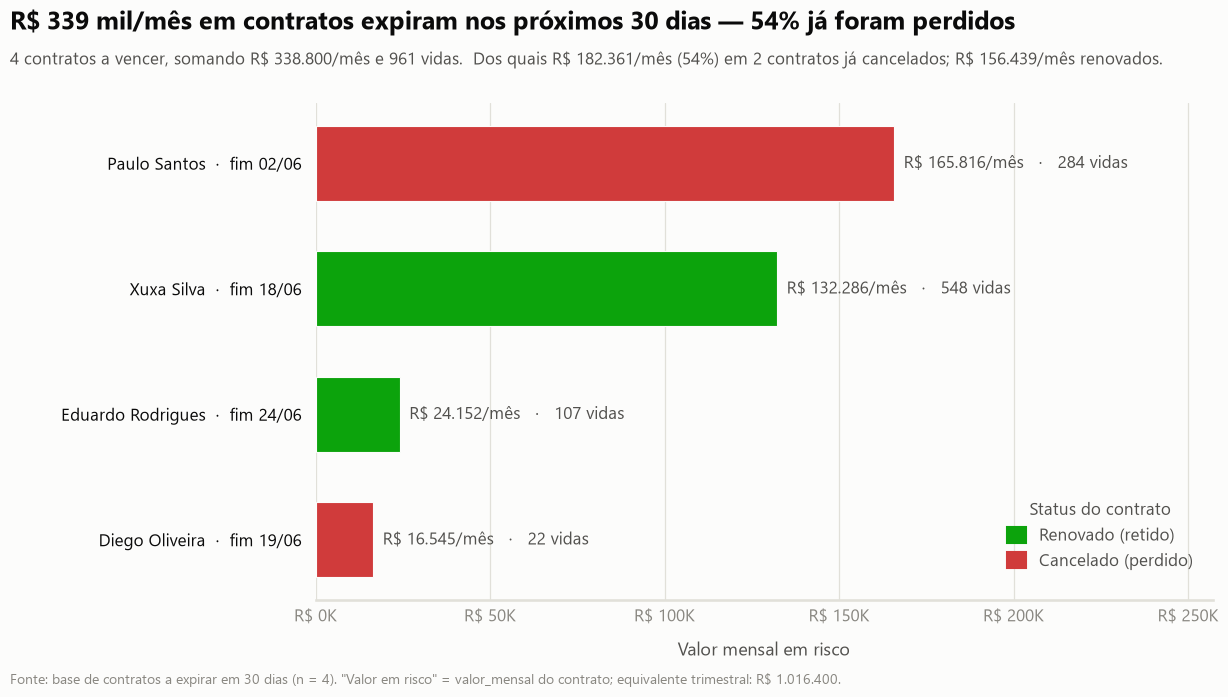

In [38]:
# ----------------------------------------------------------------------------
# Dados — contratos com vigência a expirar nos próximos 30 dias
# ----------------------------------------------------------------------------


df = fim_contrato
df["valor_mensal"] = pd.to_numeric(df["valor_mensal"], errors="coerce")
df["num_vidas"] = pd.to_numeric(df["num_vidas"], errors="coerce")
df["data_vigencia_fim"] = pd.to_datetime(df["data_vigencia_fim"])
df["rotulo"] = df["corretor_nome"].str.title() + "  ·  fim " + df["data_vigencia_fim"].dt.strftime("%d/%m")

df = df.sort_values("valor_mensal", ascending=True).reset_index(drop=True)

total_risco = df["valor_mensal"].sum()
vidas_risco = df["num_vidas"].sum()
cancelado_val = df.loc[df["status"] == "CANCELADO", "valor_mensal"].sum()
renovado_val = df.loc[df["status"] == "RENOVADO", "valor_mensal"].sum()
pct_cancelado = cancelado_val / total_risco * 100

# ----------------------------------------------------------------------------
# Paleta de status (dataviz skill: palette.md — status é reservado, nunca série)
# RENOVADO = retido (good) · CANCELADO = perdido (critical)
# ----------------------------------------------------------------------------
STATUS_ORDER = ["RENOVADO", "CANCELADO"]
STATUS_LABEL = {"RENOVADO": "Renovado (retido)", "CANCELADO": "Cancelado (perdido)"}
STATUS_COLOR = {"RENOVADO": "#0ca30c", "CANCELADO": "#d03b3b"}
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

colors = df["status"].map(STATUS_COLOR)
bars = ax.barh(df["rotulo"], df["valor_mensal"], color=colors, height=0.60,
               zorder=3, edgecolor=SURFACE, linewidth=0.8)

# Rótulo de valor + vidas no fim de cada barra
for bar, val, vidas in zip(bars, df["valor_mensal"], df["num_vidas"]):
    ax.text(bar.get_width() + total_risco * 0.008, bar.get_y() + bar.get_height() / 2,
            f"R$ {val:,.0f}".replace(",", ".") + f"/mês   ·   {vidas:.0f} vidas",
            va="center", ha="left", fontsize=12, color=INK_SECONDARY)

ax.grid(axis="x", color=GRIDLINE, linewidth=0.9, zorder=0)
ax.grid(axis="y", visible=False)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)

ax.set_xlim(0, df["valor_mensal"].max() * 1.55)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R$ {x/1000:,.0f}K".replace(",", "."))
)
ax.tick_params(axis="x", labelsize=12, length=0, pad=6)
ax.tick_params(axis="y", labelsize=12.5, length=0, pad=10)
ax.set_xlabel("Valor mensal em risco", fontsize=13, color=INK_SECONDARY, labelpad=12)

# Título / storytelling
fig.text(0.045, 0.955,
         "R$ 339 mil/mês em contratos expiram nos próximos 30 dias — 54% já foram perdidos",
         fontsize=18, fontweight="bold", color=INK_PRIMARY, ha="left")
fig.text(0.045, 0.905,
         "4 contratos a vencer, somando " +
         f"R$ {total_risco:,.0f}/mês".replace(",", ".") +
         f" e {vidas_risco:.0f} vidas.  Dos quais R$ {cancelado_val:,.0f}/mês".replace(",", ".") +
         f" ({pct_cancelado:.0f}%) em 2 contratos já cancelados; "
         f"R$ {renovado_val:,.0f}/mês".replace(",", ".") + " renovados.",
         fontsize=12.5, color=INK_SECONDARY, ha="left")

# Legenda de status
handles = [plt.Rectangle((0, 0), 1, 1, color=STATUS_COLOR[s]) for s in STATUS_ORDER]
legend = ax.legend(handles, [STATUS_LABEL[s] for s in STATUS_ORDER],
                   title="Status do contrato", loc="lower right",
                   bbox_to_anchor=(0.995, 0.03), frameon=False,
                   fontsize=12, title_fontsize=12.5, handlelength=1.1, handleheight=1.1)
legend.get_title().set_color(INK_SECONDARY)
for t in legend.get_texts():
    t.set_color(INK_SECONDARY)

fig.text(0.045, 0.02,
         "Fonte: base de contratos a expirar em 30 dias (n = 4). "
         "\"Valor em risco\" = valor_mensal do contrato; equivalente trimestral: "
         f"R$ {df['valor_mensal'].sum()*3:,.0f}.".replace(",", "."),
         fontsize=10, color=INK_MUTED, ha="left")

plt.subplots_adjust(left=0.28, right=0.97, top=0.85, bottom=0.14)



## Sinistralidade por empresa nos últimos 12 meses, sinalizando as empresas acima de um limiar de risco que você definir (e justifique o limiar).


### Sinistralidade por Empresa — Últimos 12 Meses

**Base:** 5.272 eventos de sinistro (jun/2024 – jun/2025) · 40 empresas
**Sinistralidade global da carteira:** 37% (R\$ 98,5 mi em sinistros ÷ R\$ 269,5 mi em prêmios)

---


### Metodologia de Cálculo da Sinistralidade

### 1. Definição

Sinistralidade (*loss ratio*) é a razão entre o custo assistencial gerado por uma carteira e a receita de prêmio correspondente ao **mesmo período de exposição**:

$$\text{Sinistralidade} = \frac{\sum \text{valor dos sinistros no período}}{\sum \text{prêmio ganho no período}}$$

O ponto crítico está no denominador. Sinistralidade não compara sinistro com o valor contratual do plano, e sim com o **prêmio ganho** (*earned premium*) — apenas a fração da receita correspondente ao tempo em que o contrato esteve efetivamente vigente dentro da janela analisada.

A distinção entre prêmio ganho e prêmio anualizado é o erro mais comum nesse cálculo, e está tratada na seção 8.

### 2. Data de referência e janela de análise

A data de referência do case é **30/06/2025** (definida no dicionário de dados como o "hoje" da operação). Todas as janelas são ancoradas nela.

A janela de 12 meses é expressa como:

```sql
data BETWEEN date_add('month', -12, DATE '2025-06-30') AND DATE '2025-06-30'
```

o que resolve para o intervalo **30/06/2024 a 30/06/2025**.

Esse filtro é aplicado sobre o **mês de competência**, e não sobre a data do evento. Como o mês de competência é sempre representado pelo primeiro dia do mês, os meses que satisfazem a condição são:

**2024-07, 2024-08, 2024-09, 2024-10, 2024-11, 2024-12, 2025-01, 2025-02, 2025-03, 2025-04, 2025-05, 2025-06** — exatamente 12 competências.

A competência 2024-06 fica de fora porque `2024-06-01 < 2024-06-30`. Esse detalhe é intencional: se o filtro fosse aplicado diretamente sobre a data do evento, a janela cobriria 12 meses **e um dia** (30/06/2024 inclusive), gerando uma sobreposição espúria com o período anterior.

### 3. Vigência do contrato e meses de competência

Cada contrato carrega duas datas que delimitam sua exposição: `vigencia_inicio` e `vigencia_fim`. A partir delas derivamos os **meses de competência do contrato**, que são todos os primeiros-de-mês entre o mês de início e o mês de fim, inclusive:

```
meses_do_contrato = sequência mensal de
    date_trunc('month', vigencia_inicio)  até  date_trunc('month', vigencia_fim)
```

A exposição efetiva usada no cálculo é a **interseção** entre os meses do contrato e os 12 meses da janela:

```
meses_considerados = meses_do_contrato ∩ meses_da_janela
```

Um contrato só entra no cálculo pelos meses em que essas duas condições são verdadeiras simultaneamente. Por isso contratos vendidos no meio da janela, ou que venceram no meio dela, contribuem com menos de 12 meses de prêmio — e é isso que a métrica exige.

#### Exemplo de derivação

Contrato com vigência de **04/04/2025 a 04/04/2026**:

- meses do contrato: 2025-04 até 2026-04
- interseção com a janela (2024-07 a 2025-06): **2025-04, 2025-05, 2025-06**
- exposição considerada: **3 meses**, e não 12

#### Premissa explícita: sem pró-rata

O prêmio é lançado **integralmente** no mês de entrada e no mês de saída, sem rateio por dias. Um contrato que inicia em 28/04 recebe o mês de abril cheio.

Consequência a registrar: um contrato com 12 meses corridos de vigência cujas pontas caem no meio do mês ocupa **13 meses-calendário** (no exemplo acima, 2025-04 a 2026-04), e portanto é cobrado por 13 competências quando totalmente contido na janela. Isso infla levemente a exposição e, por consequência, **subestima levemente** a sinistralidade. Se for necessária precisão maior, o refinamento é ratear o prêmio das pontas pelos dias vigentes (`dias_vigentes_no_mês / dias_do_mês`).

#### 4. Composição do prêmio ganho

Para cada par (contrato, mês de competência) considerado, o prêmio ganho é o valor mensal do contrato:

$$\text{prêmio\_ganho} = \sum_{\text{contrato}} \; \sum_{\text{mês} \, \in \, \text{meses considerados}} \text{valor\_mensal}_{\text{contrato}}$$

Contratos **sem nenhum sinistro** no período permanecem no denominador. Eles pagam prêmio e simplesmente não geraram custo — removê-los inflaria artificialmente a sinistralidade. Isso exige que o cálculo parta da base de contratos e traga os sinistros por junção externa (`LEFT JOIN`), nunca o contrário.

#### 5. Alocação dos sinistros

Cada evento de utilização é alocado ao par (contrato, mês) pela **data do evento**:

```
mês_do_sinistro = date_trunc('month', data_evento)
```

O evento entra no cálculo quando o par (contrato, mês) resultante existe na malha de meses considerados da seção 3. Na prática isso impõe duas condições: o evento ocorreu dentro da vigência do contrato e dentro da janela de 12 meses.

O vínculo evento → contrato é indireto, percorrendo `utilização → beneficiário → contrato`. A atribuição à empresa vem do contrato, não do beneficiário — os dois normalmente coincidem, mas fixar a origem evita divergência silenciosa.

#### 6. O cálculo passo a passo

Consolidando, o procedimento é:

**Passo 1.** Gerar a malha de 12 meses de competência da janela, a partir da dimensão de datas, filtrando o primeiro dia de cada mês.

**Passo 2.** Para cada contrato, recuperar `vigencia_inicio` e `vigencia_fim` e cruzar com a malha, mantendo apenas os meses em que o contrato estava vigente. Cada linha sobrevivente é um par (contrato, mês) e carrega `valor_mensal` como prêmio ganho daquele mês.

**Passo 3.** Agregar os sinistros por (contrato, mês de evento), somando `valor_sinistro`.

**Passo 4.** Unir o resultado do passo 3 ao do passo 2 por junção externa à esquerda, preenchendo com zero os meses sem sinistro.

**Passo 5.** Somar numerador e denominador por empresa e dividir.

### Exemplo numérico completo: EMPRESA K37

| Item | Valor |
|---|---|
| `valor_mensal` do contrato | R$ 16.782,14 |
| Meses vigentes dentro da janela | 7 |
| Prêmio ganho (7 × 16.782,14) | R$ 117.474,98 |
| Sinistros alocados no período | R$ 1.431.446,60 |
| **Sinistralidade** | **12,19** |

Para comparação, o mesmo contrato calculado com prêmio anualizado (12 × 16.782,14 = R$ 201.385,68) produziria uma sinistralidade de 7,11 — subestimando o risco em 42%.


#### 8. Erro comum: extrapolação do prêmio

O erro mais frequente é usar o prêmio anualizado (`valor_mensal × 12`) como denominador de uma janela de 12 meses. A premissa implícita é que todo contrato esteve vigente os 12 meses, o que raramente é verdade.

Nesta base a exposição média foi de **6,0 meses** (mediana 6), porque as vigências atravessam as bordas da janela e cada empresa mantém em média 2,7 contratos com datas escalonadas. O efeito agregado:

| Base de cálculo do prêmio | Total |
|---|---|
| Prêmio anualizado (`valor_mensal × 12`) | R$ 265.248.586,32 |
| Prêmio ganho (exposição real) | R$ 139.048.776,39 |
| Fator de inflação do denominador | **1,91×** |

O viés é **sistemático e unidirecional**: como nenhum contrato pode ficar vigente mais de 12 meses numa janela de 12 meses, a extrapolação só pode inflar o denominador. A sinistralidade calculada assim é sempre otimista, nunca conservadora.

Um segundo erro, mais sutil, é partir da tabela de sinistros e trazer os contratos por junção interna. Isso remove do denominador todo contrato sem sinistro no período, inflando a métrica na direção oposta. O cálculo precisa partir da exposição.

#### 9. Limitações conhecidas desta base

A regra da seção 5 descarta sinistros ocorridos fora da vigência do contrato. Nesta base o volume descartado é material e precisa ser declarado:

| Componente | Valor (R$) | Participação |
|---|---|---|
| Alocado (dentro da vigência e da janela) | 72.485.914,69 | 73,6% |
| Sinistro posterior ao fim da vigência | 25.829.556,09 | 26,2% |
| Borda da janela (competência 2024-06) | 136.675,68 | 0,1% |
| **Total de sinistro na janela por data do evento** | **98.452.146,46** | 100% |

Os 26,2% descartados têm causa identificada e não são ruído aleatório. Todos ocorrem **após** o `vigencia_fim` (nenhum antes do início), com mediana de 131 dias depois do vencimento. Dos 1.558 eventos nessa situação, 1.170 pertencem a contratos com status `RENOVADO`, e **71,7% do valor tem outro contrato ativo da mesma empresa na data do evento**. O diagnóstico é que o campo `contrato_id` do beneficiário não é reapontado para o contrato sucessor no momento da renovação, de modo que os sinistros continuam sendo escriturados no contrato vencido.

Impacto sobre o resultado: a sinistralidade global calculada no grão contrato × mês é **0,52**. Atribuindo os sinistros à **empresa** em vez do contrato — vínculo confiável, já que o beneficiário pertence à empresa independentemente de qual contrato esteja ativo — o indicador sobe para **0,71**.

Consequência prática: para ranking e priorização de carteira, recomenda-se calcular a sinistralidade no grão **empresa × mês**, o que contorna o vínculo quebrado sem depender de correção na origem. O grão contrato × mês permanece válido para análise de rentabilidade por apólice, desde que a limitação seja declarada.

Registre-se ainda que uma empresa (EMPRESA I09) apresenta sinistros na janela sem nenhum mês de vigência dentro dela, e por isso não aparece no resultado calculado pela exposição.

#### 10. Parâmetros do cálculo

| Parâmetro | Valor adotado |
|---|---|
| Data de referência | 30/06/2025 |
| Janela | 12 meses (competências 2024-07 a 2025-06) |
| Unidade de competência | Mês, representado pelo primeiro dia |
| Base do prêmio | Prêmio ganho (`valor_mensal` por mês vigente) |
| Rateio nas pontas | Não aplicado (mês integral) |
| Contratos sem sinistro | Mantidos no denominador |
| Sinistro fora da vigência | Descartado no grão contrato; recuperável no grão empresa |
| Grão de cálculo | Contrato × mês de competência, agregado por empresa |


---
### Sinistralidade por Empresa — Últimos 12 Meses

**Base:** base consolidada de sinistralidade por empresa (jun/2024 – jun/2025) · 39 empresas
**Sinistralidade global da carteira:** 52% (R\$ 72,5 mi em sinistros ÷ R\$ 139,0 mi em prêmios)
**Mediana:** 59% · **Média simples:** 104% (puxada pelo outlier K37)

---


---

#### Limiar de risco definido — e por quê

Adotei **dois limiares**, ambos com base atuarial (não arbitrários):

| Limiar | Faixa | Justificativa |
|---|---|---|
| **70%** | 🟠 Alerta | Uma apólice não gasta só com sinistros: há despesas administrativas, comissão de corretagem e margem, tipicamente **25–30% do prêmio**. Acima de ~70% de sinistralidade, o que sobra do prêmio não cobre mais essas despesas — **o contrato deixa de ser rentável**. É o patamar de referência usado no setor de saúde suplementar (ANS) como teto operacional saudável. |
| **100%** | 🔴 Crítico | **Ruína técnica**: a empresa paga em sinistros **mais do que arrecadou** em prêmio. Prejuízo direto no risco, antes mesmo de somar despesas. |

**Por que 70% e não outro número:** é o ponto em que a margem operacional típica (30%) se esgota. Abaixo disso, o contrato ainda é lucrativo; entre 70% e 100%, consome a margem mas ainda gera caixa no risco; acima de 100%, destrói valor.

---

### Empresas acima do limiar (16 de 39 — 41% da carteira)

#### 🔴 Críticas — sinistralidade ≥ 100% (8 empresas)

| Empresa | Setor | Porte | Sinistralidade | Sinistros | Prêmio | Prejuízo técnico |
|---|---|---|---|---|---|---|
| **K37** | Agronegócio | Grande | **1.219%** | R\$ 1,43 mi | R\$ 117 mil | R\$ 1,31 mi |
| **G07** | Indústria | Pequena | **266%** | R\$ 1,84 mi | R\$ 692 mil | R\$ 1,15 mi |
| **N40** | Indústria | Grande | **247%** | R\$ 1,43 mi | R\$ 577 mil | R\$ 851 mil |
| **I35** | Agronegócio | Pequena | **183%** | R\$ 1,61 mi | R\$ 879 mil | R\$ 727 mil |
| **T20** | Saúde | Grande | **182%** | R\$ 3,92 mi | R\$ 2,15 mi | **R\$ 1,77 mi** |
| **P16** | Educação | Média | **152%** | R\$ 1,56 mi | R\$ 1,03 mi | R\$ 531 mil |
| **U21** | Saúde | Grande | **147%** | R\$ 666 mil | R\$ 452 mil | R\$ 214 mil |
| **D04** | Indústria | Média | **131%** | R\$ 2,86 mi | R\$ 2,19 mi | R\$ 671 mil |

**Prejuízo técnico somado das 8 críticas: R\$ 7,23 milhões.**

#### 🟠 Alerta — sinistralidade entre 70% e 100% (8 empresas)

| Empresa | Setor | Porte | Sinistralidade |
|---|---|---|---|
| **E31** | Serviços Financeiros | Pequena | 97% |
| **N14** | Educação | Pequena | 94% |
| **R18** | Serviços Financeiros | Média | 88% |
| **E05** | Tecnologia | Média | 88% |
| **M13** | Educação | Grande | 81% |
| **D30** | Serviços Financeiros | Grande | 80% |
| **Z26** | Agronegócio | Grande | 78% |
| **O15** | Saúde | Pequena | 77% |

---

#### Principais insights

1. **Quatro em cada dez empresas da carteira estão acima do limiar de risco.** São **16 de 39** empresas acima de 70%, sendo **8 já em ruína técnica** (>100%). Com sinistralidade global de 52%, a carteira ainda é lucrativa no agregado — mas a margem está sendo corroída por um bloco relevante de contratos deficitários.

2. **T20 é a prioridade real de ação, não a K37.** Embora K37 tenha o maior percentual (1.219%), o **maior prejuízo em reais é da T20: R\$ 1,77 mi** (sinistralidade de 182% sobre um prêmio grande, de R\$ 2,15 mi). Percentual alto sobre prêmio pequeno gera manchete; percentual alto sobre prêmio grande gera prejuízo. Para reprecificação, a ordem por impacto é **T20 → K37 → G07 → N40**.

3. **K37 continua sendo um caso de investigação, não de reprecificação.** Com RS 1,43 mi de sinistros contra apenas R\$ 117 mil de prêmio, o número é implausível como operação normal. Antes de qualquer decisão comercial, vale checar se há erro de cadastro, contrato encerrado precocemente ou concentração de eventos catastróficos. *(A K37 também apareceu como anomalia na análise de faturamento — menor valor da base apesar de classificada como "Grande".)*

4. **O risco não segue setor nem porte.** As 16 sinalizadas se distribuem de forma quase uniforme por setor (Agronegócio, Indústria, Saúde, Educação e Serviços Financeiros com 3 cada) e por porte (7 Grandes, 5 Pequenas, 4 Médias). Não há um segmento "culpado" — o risco é **específico da empresa/contrato**, o que reforça a necessidade de monitoramento individual em vez de política por segmento.

5. **Há um grupo grande na zona limítrofe.** Além das 16 sinalizadas, três empresas estão logo abaixo do corte — **L12 (69%), F06 (68%) e Y25 (67%)**. Uma piora marginal de sinistros as coloca em alerta, então valem acompanhamento preventivo.

---

#### Ressalvas metodológicas


- O outlier K37 distorce estatísticas agregadas: a **média simples de sinistralidade é 104%, contra mediana de 59%**. Para leitura de "empresa típica", use a mediana; a média só faz sentido ponderada por prêmio (que é a sinistralidade global, 52%).

---
*Gráfico correspondente: `sinistralidade_por_empresa.png` · Script: `plot_sinistralidade.py`*




In [62]:
sinistralidade_base = wr.athena.read_sql_query(
    sql="""select fmc.sk_empresa,
    de.empresa_nome,
    sum(fmc.valor_sinistros_mes) valor_sinistro,
    sum(fmc.premio_competencia) valor_premio,
    sum(fmc.valor_sinistros_mes)/sum(fmc.premio_competencia) sinistralidade
from fct_mensal_contrato fmc
inner join dim_data dd on dd.sk_data = fmc.sk_mes_competencia
inner join dim_empresa de on de.sk_empresa = fmc.sk_empresa
where dd.data BETWEEN
    date_add('month', -12, DATE '2025-06-30')
    AND DATE '2025-06-30'
group by 1,2 
order by 5 desc
        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

saved: C:\Users\gnose\Downloads\sinistralidade_por_empresa.png
n=39 | alerta>=70%: 16 | critico>=100%: 8 | global 52.1%


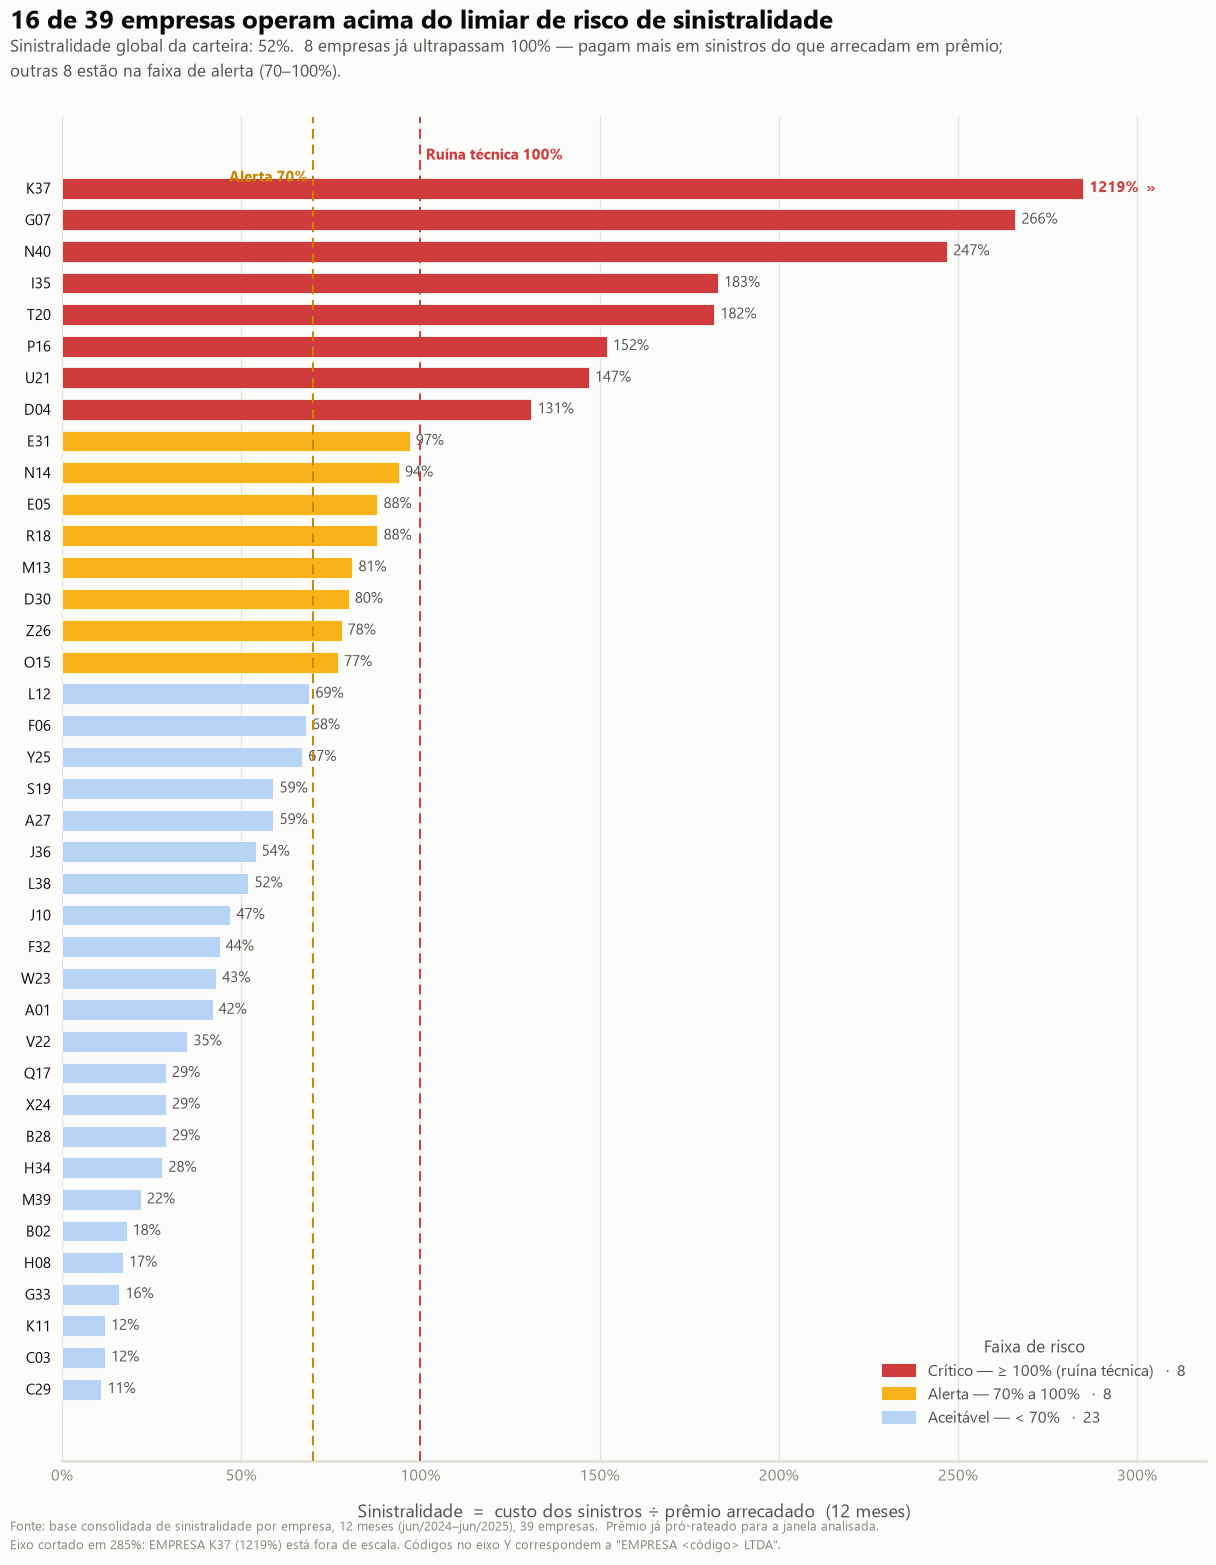

In [64]:
# ----------------------------------------------------------------------------
# Dados — sinistralidade ja consolidada por empresa (12 meses)
# ----------------------------------------------------------------------------
SRC = r"C:\Users\gnose\Downloads\0c632e3d-78f5-436e-b565-32ba570e7637 (2).csv"
SRC_EVENTOS = r"C:\Users\gnose\Downloads\2f77874e-0823-491d-b9ce-e346a4c087ad.csv"
OUT_PNG = r"C:\Users\gnose\Downloads\sinistralidade_por_empresa.png"

res = sinistralidade_base
res["sin_pct"] = res["sinistralidade"] * 100

# setor/porte nao vem no consolidado — recuperados da base de eventos
meta = (pd.read_csv(SRC_EVENTOS)
          .drop_duplicates("empresa_nome")
          .set_index("empresa_nome")[["setor", "porte"]])
res = res.join(meta, on="empresa_nome")

res["codigo"] = res["empresa_nome"].str.extract(r"EMPRESA\s+(\w+)\s+LTDA")
res = res.sort_values("sin_pct", ascending=True).reset_index(drop=True)

# ----------------------------------------------------------------------------
# Limiares de risco (justificativa no .md)
#   70%  = limiar de alerta economico (premio consome-se em sinistros +
#          ~25-30% de despesas/comissao -> contrato deixa de ser rentavel)
#   100% = ruina tecnica (sinistros >= premio arrecadado)
# ----------------------------------------------------------------------------
THR_ALERTA = 70
THR_CRITICO = 100

C_OK = "#b7d3f6"       # aceitavel (< 70%) — azul claro, recende
C_ALERTA = "#fab219"   # atencao (70-100%) — status warning
C_CRITICO = "#d03b3b"  # critico (>= 100%) — status critical

def classify(v):
    if v >= THR_CRITICO:
        return C_CRITICO
    if v >= THR_ALERTA:
        return C_ALERTA
    return C_OK

res["cor"] = res["sin_pct"].map(classify)

INK_PRIMARY = "#0b0b0b"; INK_SECONDARY = "#52514e"; INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"; SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_PRIMARY,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
})

fig, ax = plt.subplots(figsize=(13, 16))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

XMAX = 285  # eixo cortado: K37 (1219%) fica off-scale e recebe rotulo explicito
bars = ax.barh(res["codigo"], res["sin_pct"].clip(upper=XMAX),
               color=res["cor"], height=0.66, zorder=3,
               edgecolor=SURFACE, linewidth=0.6)

for bar, val in zip(bars, res["sin_pct"]):
    clipped = val > XMAX
    x = XMAX if clipped else bar.get_width()
    txt = (f"{val:.0f}%  »" if clipped else f"{val:.0f}%")
    ax.text(x + XMAX * 0.006, bar.get_y() + bar.get_height() / 2, txt,
            va="center", ha="left", fontsize=10.5,
            color=(C_CRITICO if clipped else INK_SECONDARY),
            fontweight=("bold" if clipped else "normal"))

# Linhas de limiar (rotulos escalonados para nao colidir)
for thr, col, lbl, dy, ha in [
        (THR_ALERTA, "#c98500", "Alerta 70%", 0.9, "right"),
        (THR_CRITICO, C_CRITICO, "Ruína técnica 100%", 0.2, "left")]:
    ax.axvline(thr, color=col, linewidth=1.4, linestyle=(0, (5, 3)), zorder=4)
    ax.text(thr + (1.5 if ha == "left" else -1.5), len(res) - dy, lbl,
            ha=ha, va="bottom", fontsize=11, color=col, fontweight="bold")

ax.grid(axis="x", color=GRIDLINE, linewidth=0.9, zorder=0)
ax.grid(axis="y", visible=False); ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)
ax.set_xlim(0, XMAX * 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.tick_params(axis="x", labelsize=11.5, length=0, pad=6)
ax.tick_params(axis="y", labelsize=10.5, length=0, pad=8)
ax.set_xlabel("Sinistralidade  =  custo dos sinistros ÷ prêmio arrecadado  (12 meses)",
              fontsize=13, color=INK_SECONDARY, labelpad=14)

n_tot = len(res)
n_alerta = int((res["sin_pct"] >= THR_ALERTA).sum())
n_critico = int((res["sin_pct"] >= THR_CRITICO).sum())
sin_global = res["valor_sinistro"].sum() / res["valor_premio"].sum() * 100

fig.text(0.045, 0.982,
         f"{n_alerta} de {n_tot} empresas operam acima do limiar de risco de sinistralidade",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.045, 0.966,
         f"Sinistralidade global da carteira: {sin_global:.0f}%.  "
         f"{n_critico} empresas já ultrapassam 100% — pagam mais em sinistros do que arrecadam em prêmio;\n"
         f"outras {n_alerta - n_critico} estão na faixa de alerta (70–100%).",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top", linespacing=1.5)

# Legenda de faixas de risco
handles = [
    mpatches.Patch(color=C_CRITICO, label=f"Crítico — ≥ 100% (ruína técnica)   ·  {n_critico}"),
    mpatches.Patch(color=C_ALERTA, label=f"Alerta — 70% a 100%   ·  {n_alerta - n_critico}"),
    mpatches.Patch(color=C_OK, label=f"Aceitável — < 70%   ·  {n_tot - n_alerta}"),
]
leg = ax.legend(handles=handles, title="Faixa de risco", loc="lower right",
                bbox_to_anchor=(0.995, 0.015), frameon=False,
                fontsize=11.5, title_fontsize=12)
leg.get_title().set_color(INK_SECONDARY)
for t in leg.get_texts():
    t.set_color(INK_SECONDARY)

fig.text(0.045, 0.016,
         f"Fonte: base consolidada de sinistralidade por empresa, 12 meses (jun/2024–jun/2025), {n_tot} empresas.  "
         "Prêmio já pró-rateado para a janela analisada.\n"
         f"Eixo cortado em {XMAX}%: EMPRESA K37 ({res['sin_pct'].max():.0f}%) está fora de escala. "
         "Códigos no eixo Y correspondem a \"EMPRESA <código> LTDA\".",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom", linespacing=1.5)

plt.subplots_adjust(left=0.085, right=0.965, top=0.915, bottom=0.075)
fig.savefig(OUT_PNG, dpi=200, facecolor=SURFACE)
print("saved:", OUT_PNG)
print(f"n={n_tot} | alerta>=70%: {n_alerta} | critico>=100%: {n_critico} | global {sin_global:.1f}%")


# Deep dive: quem são os nossos usuários e onde atuar 

## Como se distribui o custo? Que fração dos beneficiários concentra a maior parte dos sinistros (high cost claimants)? O que caracteriza esse grupo (idade, sexo, tipo de evento, especialidade)?


### High-Cost Claimants — Concentração e Perfil do Custo Assistencial

**Base:** 6.465 eventos de sinistro · 1.424 beneficiários · **R\$ 121,1 mi** em custo assistencial
*(15 eventos sem beneficiário identificado — R\$ 119 mil — foram excluídos das análises por pessoa.)*

---

### 1. Como se distribui o custo?

A distribuição é **fortemente concentrada e assimétrica**, mas não tão extrema quanto o padrão clássico do setor.

| Corte | Nº de pessoas | % do custo |
|---|---|---|
| Top 1% | 15 | **10,5%** |
| Top 2% | 29 | 17,0% |
| **Top 5%** | **72** | **28,0%** |
| Top 10% | 143 | 40,9% |
| Top 20% | 285 | 59,9% |
| Top 50% | 712 | 92,3% |

- **Índice de Gini = 0,61** — concentração alta.
- **Metade de todo o custo vem de apenas 14% dos beneficiários.**
- **80% do custo vem de 35% dos beneficiários.**
- Custo por pessoa: mediana R\$ 56 mil · média R\$ 85 mil · p90 R\$ 198 mil · **máximo R\$ 1,17 mi**. A média ser 52% maior que a mediana confirma a cauda longa à direita.

> **Comparação com o benchmark:** na literatura de saúde suplementar, o padrão típico é *top 5% ≈ 50% do custo*. Aqui o top 5% responde por 28% — ou seja, a concentração é **relevante mas mais difusa que o usual**. Isso muda a estratégia: gestão focada apenas nos 72 maiores casos endereça pouco mais de um quarto do gasto. Para mover a agulha de verdade, é preciso alcançar o top 20% (60% do custo).

---

### 2. O que caracteriza o grupo de high-cost claimants?

Defini **HCC = top 5% dos beneficiários por custo acumulado** (72 pessoas, R\$ 33,8 mi). O achado central é contraintuitivo:

#### 🔑 O que separa o grupo é **recorrência**, não perfil demográfico

| Métrica | HCC (top 5%) | Demais | Razão |
|---|---|---|---|
| Eventos por beneficiário | **14,3** | 4,0 | **3,6×** |
| Custo médio por evento | R\$ 32.876 | R\$ 16.085 | 2,0× |
| **Custo total por beneficiário** | **R\$ 469.852** | R\$ 64.493 | **7,3×** |

O custo 7,3× maior se decompõe em **3,6× de frequência × 2,0× de severidade**. Ou seja, **a frequência de utilização explica mais do que o dobro do que a gravidade do evento explica**. Não é um grupo de pessoas com um evento catastrófico isolado — é um grupo que **volta ao sistema repetidamente**.

#### ❌ O que NÃO caracteriza o grupo

| Dimensão | Resultado |
|---|---|
| **Idade** | Praticamente idêntica: mediana **43 anos (HCC) vs 46 (demais)**; média 42,8 vs 44,4. A distribuição etária dos dois grupos é sobreposta. **Idade não é preditor aqui.** |
| **Faixa etária 59+** | Representa 20,8% do custo HCC vs 24,7% dos demais — ou seja, os idosos pesam *menos* no grupo caro, não mais. |
| **Sexo** | Leve sobre-representação masculina no HCC (M 60% do custo com sexo informado vs 47% nos demais), mas comprometida por 19% de dados faltantes (ver ressalvas). |
| **Especialidade** | Nenhuma domina. A maior diferença é Ginecologia (+6,0 p.p.), seguida de Oftalmologia (+1,9 p.p.). Todas as demais ficam em ±2,5 p.p. |
| **Tipo de beneficiário** | Titular/dependente na mesma proporção dos demais (~57%/43%). |

#### ✅ O que de fato diferencia

- **Cirurgia** responde por **69% do custo HCC** (vs 61% nos demais) — junto com internação, são **98% do gasto do grupo**.
- Procedimentos de baixo custo unitário (consulta, exame, terapia, pronto-socorro) somam **menos de 0,5%** do custo HCC.

---

### 3. Informações críticas adicionais

Além do que foi perguntado, três pontos que considero decisivos para agir sobre esse problema:

#### 3.1 Pronto-socorro evitável é um problema de volume, não de custo
Eventos marcados como PS evitável são **9,5% de todos os eventos**, mas apenas **0,7% do custo** (R\$ 853 mil). É um indicador relevante de má navegação assistencial e sobrecarga da rede, mas **não é onde está o dinheiro**. Priorizá-lo como iniciativa de redução de custo seria um erro de alocação de esforço.

#### 3.2 A frequência é o alvo acionável — e isso muda o tipo de intervenção
Como o driver é recorrência (14,3 eventos/pessoa) e não evento catastrófico isolado, as alavancas que funcionam são diferentes:
- **Gestão de casos crônicos / coordenação de cuidado** para os 72 HCC, com foco em reduzir reinternações e recirurgias.
- **Não** faz sentido apostar apenas em negociação de tabela ou teto de procedimento — isso ataca a severidade (2,0×), que é o componente menor.

#### 3.3 Rotatividade pode estar mascarando risco
14% dos HCC têm data de cancelamento registrada (vs 11% dos demais). Se beneficiários de alto custo estão saindo da carteira, o custo observado pode estar **subestimando a exposição real** de quem permanece — e, se houver seleção adversa na entrada, o problema tende a se repetir com novos entrantes. Vale medir custo *per capita ajustado por tempo de exposição*, não custo absoluto.

---

### 4. Ressalvas metodológicas

- **19% dos eventos não têm `sexo` preenchido** (1.241 eventos, 277 beneficiários). A ausência é **sistemática por beneficiário** — nenhum beneficiário tem o campo ora preenchido, ora vazio —, o que sugere falha de cadastro em um subconjunto de pessoas, não erro aleatório de digitação. Qualquer conclusão por sexo é frágil até isso ser corrigido.
- A janela temporal do dado não foi normalizada por tempo de permanência: um beneficiário que entrou há 2 meses tem menos oportunidade de acumular custo que um de 2 anos. Como parte do efeito "frequência" pode ser tempo de exposição, o ideal é recalcular como **eventos por beneficiário-mês**.
- O corte de 5% é convenção de mercado para HCC. Dado que aqui a concentração é mais difusa que o padrão, **um corte em 10% ou 20% pode ser operacionalmente mais útil** para desenhar programas de gestão.

---


In [66]:
custo_distr = wr.athena.read_sql_query(
    sql="""select fu.*,
    des.tipo_evento,
    des.especialidade,
    des.grupo_evento,
    des.flag_ps_evitavel,
    db.sexo,
    db.data_nascimento,
    db.idade,
    db.faixa_etaria,
    db.tipo_beneficiario,
    db.data_adesao,
    db.data_cancelamento,
    db.flag_ativo
from fct_utilizacao fu
inner join dim_evento_saude des on des.sk_evento_saude = fu.sk_evento_saude
left join dim_beneficiario db on db.sk_beneficiario = fu.sk_beneficiario
--fct utilizacao: 6465

        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)


Gini 0.611 | top1% 10.5% | top5% 28.0% | top10% 40.9% | top20% 59.9%
             custo    ev    bn  freq      sev  custo_pc
grupo                                                  
Demais  87194234.8  5421  1352   4.0  16084.5   64492.8
HCC     33829346.4  1029    72  14.3  32875.9  469852.0


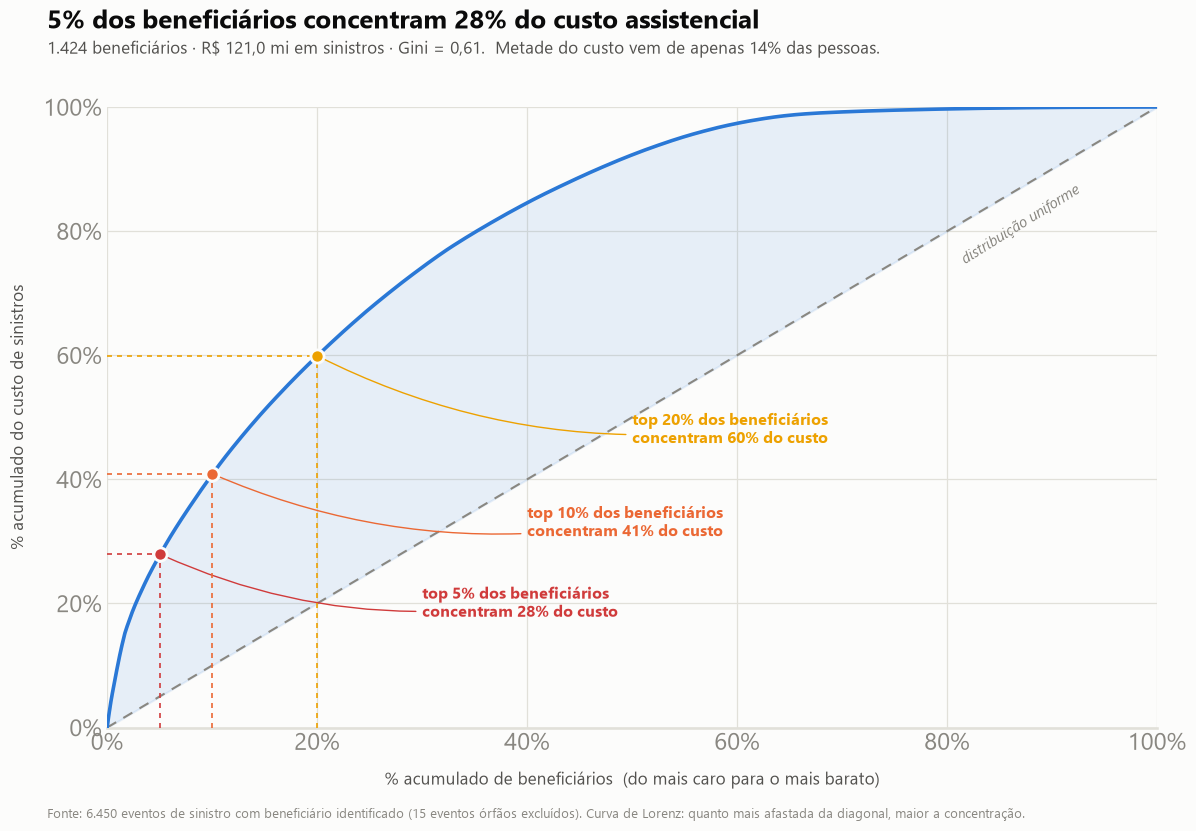

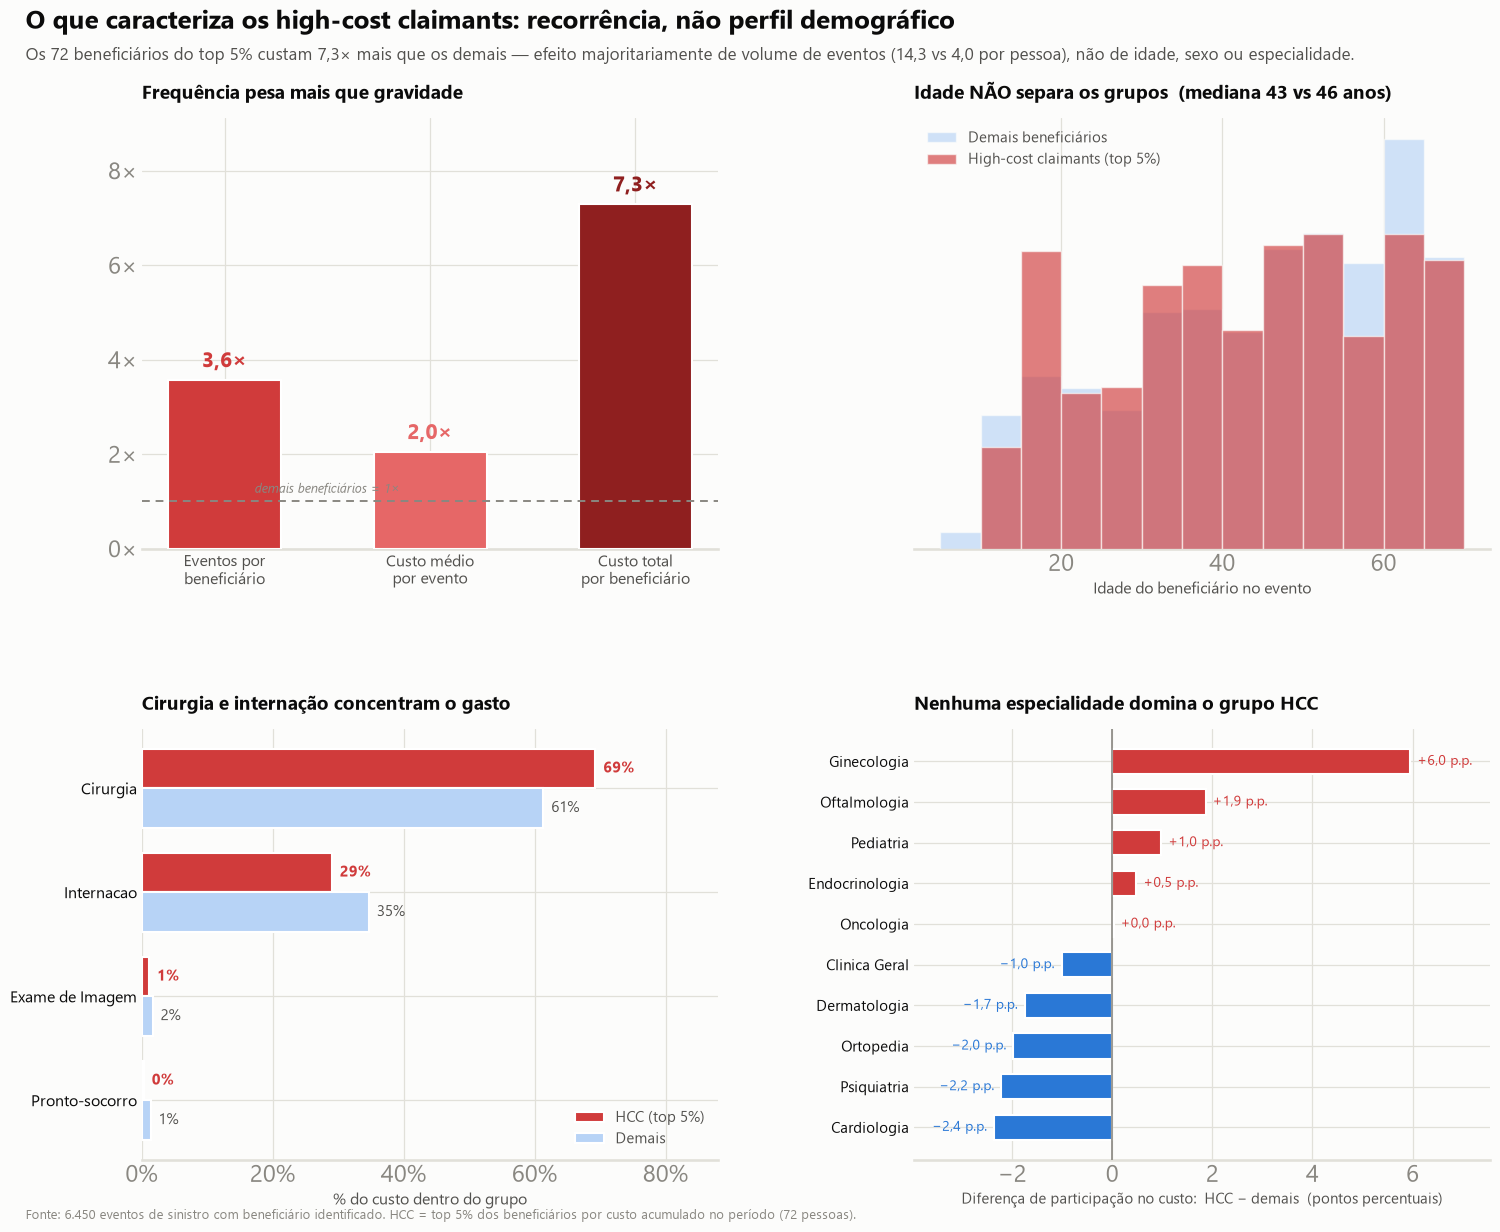

In [72]:

raw = custo_distr

# Alguns backends do pandas devolvem decimal.Decimal nessas colunas, o que
# quebra as operacoes com float mais adiante. Forcamos float64 nativo.
for col in ["valor_sinistro", "idade", "sk_beneficiario"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce").astype("float64")

df = raw.dropna(subset=["sk_beneficiario"]).copy()   # 15 eventos orfaos excluidos

# Custo agregado por beneficiario, do maior para o menor
ben = (df.groupby("sk_beneficiario")["valor_sinistro"]
         .agg(custo="sum", n_eventos="count")
         .sort_values("custo", ascending=False))
n_ben = len(ben)
custo_total = ben["custo"].sum()

ben["cum_custo_pct"] = ben["custo"].cumsum() / custo_total * 100
ben["cum_ben_pct"] = np.arange(1, n_ben + 1) / n_ben * 100

# Corte de high-cost claimants: top 5% dos beneficiarios
PCT_HCC = 5
k_hcc = int(np.ceil(n_ben * PCT_HCC / 100))
hcc_ids = set(ben.head(k_hcc).index)
df["grupo"] = np.where(df["sk_beneficiario"].isin(hcc_ids), "HCC", "Demais")

def share(p):
    k = max(1, int(np.ceil(n_ben * p / 100)))
    return ben["custo"].head(k).sum() / custo_total * 100

# Indice de Gini (concentracao)
ord_asc = np.sort(ben["custo"].values)
i = np.arange(1, n_ben + 1)
gini = (2 * (i * ord_asc).sum()) / (n_ben * ord_asc.sum()) - (n_ben + 1) / n_ben

# ----------------------------------------------------------------------------
# Estilo
# ----------------------------------------------------------------------------
C_HCC = "#d03b3b"; C_REST = "#b7d3f6"; C_ACCENT = "#2a78d6"
INK_PRIMARY = "#0b0b0b"; INK_SECONDARY = "#52514e"; INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"; SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
})

def br(v, dec=1):
    """Formata numero no padrao pt-BR (virgula decimal, ponto de milhar)."""
    s = f"{v:,.{dec}f}"
    return s.replace(",", "\x00").replace(".", ",").replace("\x00", ".")

def titulo_cat(s):
    """Title case respeitando preposicoes (EXAME DE IMAGEM -> Exame de imagem)."""
    p = s.lower().split()
    return " ".join([w if w in ("de", "da", "do") else w.capitalize() for w in p])

def clean(ax, left_spine=False):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRIDLINE, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_visible(left_spine)
    ax.spines["left"].set_color(GRIDLINE)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.tick_params(length=0)

# ============================================================================
# FIGURA 1 — Curva de concentracao (Lorenz)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 8.5))
fig.patch.set_facecolor(SURFACE)

x = np.concatenate([[0], ben["cum_ben_pct"].values])
y = np.concatenate([[0], ben["cum_custo_pct"].values])

ax.plot([0, 100], [0, 100], color=INK_MUTED, linewidth=1.5,
        linestyle=(0, (5, 4)), zorder=2)
ax.text(87, 81, "distribuição uniforme", fontsize=10.5,
        color=INK_MUTED, rotation=32, ha="center", va="center", style="italic")

ax.fill_between(x, y, x, color=C_ACCENT, alpha=0.10, zorder=1)
ax.plot(x, y, color=C_ACCENT, linewidth=2.6, zorder=4)

# Marcadores nos cortes-chave (anotacoes a direita, fora do feixe de linhas)
for p, col, tx, ty in [(5, C_HCC, 30, 20), (10, "#eb6834", 40, 33),
                        (20, "#eda100", 50, 48)]:
    s = share(p)
    ax.plot([p, p], [0, s], color=col, linewidth=1.2, linestyle=(0, (3, 3)), zorder=3)
    ax.plot([0, p], [s, s], color=col, linewidth=1.2, linestyle=(0, (3, 3)), zorder=3)
    ax.scatter([p], [s], s=90, color=col, zorder=6, edgecolor=SURFACE, linewidth=2)
    ax.annotate(f"top {p}% dos beneficiários\nconcentram {s:.0f}% do custo",
                xy=(p, s), xytext=(tx, ty),
                fontsize=11.5, color=col, fontweight="bold", va="center", ha="left",
                arrowprops=dict(arrowstyle="-", color=col, linewidth=1,
                                connectionstyle="arc3,rad=-0.15"))

clean(ax)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("% acumulado de beneficiários  (do mais caro para o mais barato)",
              fontsize=12.5, color=INK_SECONDARY, labelpad=12)
ax.set_ylabel("% acumulado do custo de sinistros", fontsize=12.5,
              color=INK_SECONDARY, labelpad=12)

fig.text(0.045, 0.975,
         f"5% dos beneficiários concentram {share(5):.0f}% do custo assistencial",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.045, 0.938,
         f"{br(n_ben, 0)} beneficiários · R$ {br(custo_total/1e6)} mi em sinistros · Gini = {br(gini, 2)}.  "
         f"Metade do custo vem de apenas {(ben['cum_custo_pct']<=50).sum()/n_ben*100:.0f}% das pessoas.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top")

fig.text(0.045, 0.02,
         "Fonte: 6.450 eventos de sinistro com beneficiário identificado (15 eventos órfãos excluídos). "
         "Curva de Lorenz: quanto mais afastada da diagonal, maior a concentração.",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.095, right=0.97, top=0.86, bottom=0.13)




# ============================================================================
# FIGURA 2 — O que caracteriza o grupo HCC (painel 2x2)
# ============================================================================
g = df.groupby("grupo").agg(custo=("valor_sinistro", "sum"),
                            ev=("valor_sinistro", "count"),
                            bn=("sk_beneficiario", "nunique"))
g["freq"] = g.ev / g.bn
g["sev"] = g.custo / g.ev
g["custo_pc"] = g.custo / g.bn

fig, axes = plt.subplots(2, 2, figsize=(15.5, 12.5))
fig.patch.set_facecolor(SURFACE)
ax1, ax2, ax3, ax4 = axes.ravel()

# --- Painel 1: decomposicao frequencia x severidade (indice, Demais = 1) ----
metricas = ["Eventos por\nbeneficiário", "Custo médio\npor evento", "Custo total\npor beneficiário"]
ratios = [g.loc["HCC", "freq"] / g.loc["Demais", "freq"],
          g.loc["HCC", "sev"] / g.loc["Demais", "sev"],
          g.loc["HCC", "custo_pc"] / g.loc["Demais", "custo_pc"]]
cores = [C_HCC, "#e66767", "#8f1f1f"]
bars = ax1.bar(metricas, ratios, color=cores, width=0.55, zorder=3)
ax1.axhline(1, color=INK_MUTED, linewidth=1.4, linestyle=(0, (4, 3)), zorder=4)
ax1.text(0.5, 1.12, "demais beneficiários = 1×", fontsize=9.5, color=INK_MUTED,
         ha="center", va="bottom", style="italic")
for bar, r, c in zip(bars, ratios, cores):
    ax1.text(bar.get_x() + bar.get_width() / 2, r + 0.18, f"{br(r)}×",
             ha="center", va="bottom", fontsize=15, fontweight="bold", color=c)
clean(ax1)
ax1.set_ylim(0, max(ratios) * 1.25)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}×"))
ax1.tick_params(axis="x", labelsize=11.5, colors=INK_SECONDARY)
ax1.set_title("Frequência pesa mais que gravidade",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")
ax1.text(0, 1.02, "", transform=ax1.transAxes)

# --- Painel 2: distribuicao de idade ---------------------------------------
for grp, col, lbl in [("Demais", C_REST, "Demais beneficiários"),
                      ("HCC", C_HCC, "High-cost claimants (top 5%)")]:
    sub = df[df["grupo"] == grp]["idade"].dropna()
    ax2.hist(sub, bins=np.arange(5, 75, 5), density=True, alpha=0.65,
             color=col, label=lbl, zorder=3, edgecolor=SURFACE, linewidth=1)
med_h = df[df.grupo == "HCC"]["idade"].median()
med_d = df[df.grupo == "Demais"]["idade"].median()
clean(ax2)
ax2.set_yticks([])
ax2.set_xlabel("Idade do beneficiário no evento", fontsize=11.5, color=INK_SECONDARY)
ax2.legend(frameon=False, fontsize=10.5, loc="upper left")
for t in ax2.get_legend().get_texts():
    t.set_color(INK_SECONDARY)
ax2.set_title(f"Idade NÃO separa os grupos  (mediana {med_h:.0f} vs {med_d:.0f} anos)",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 3: tipo de evento (% do custo dentro do grupo) -----------------
te = (df.pivot_table(index="tipo_evento", columns="grupo",
                     values="valor_sinistro", aggfunc="sum")
        .div(df.groupby("grupo")["valor_sinistro"].sum(), axis=1) * 100)
te = te.sort_values("HCC", ascending=True)
te = te[te.max(axis=1) > 1]          # esconde categorias residuais
ypos = np.arange(len(te)); h = 0.38
ax3.barh(ypos + h/2, te["HCC"], height=h, color=C_HCC, label="HCC (top 5%)", zorder=3)
ax3.barh(ypos - h/2, te["Demais"], height=h, color=C_REST, label="Demais", zorder=3)
for yy, v in zip(ypos, te["HCC"]):
    ax3.text(v + 1.2, yy + h/2, f"{v:.0f}%", va="center", fontsize=10.5, color=C_HCC, fontweight="bold")
for yy, v in zip(ypos, te["Demais"]):
    ax3.text(v + 1.2, yy - h/2, f"{v:.0f}%", va="center", fontsize=10.5, color=INK_SECONDARY)
ax3.set_yticks(ypos); ax3.set_yticklabels([titulo_cat(t) for t in te.index], fontsize=11.5)
ax3.tick_params(axis="y", colors=INK_PRIMARY)
clean(ax3)
ax3.set_xlim(0, 88)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax3.set_xlabel("% do custo dentro do grupo", fontsize=11.5, color=INK_SECONDARY)
ax3.legend(frameon=False, fontsize=10.5, loc="lower right")
for t in ax3.get_legend().get_texts():
    t.set_color(INK_SECONDARY)
ax3.set_title("Cirurgia e internação concentram o gasto",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 4: especialidade — diferenca de share (HCC - demais) -----------
es = (df.pivot_table(index="especialidade", columns="grupo",
                     values="valor_sinistro", aggfunc="sum")
        .div(df.groupby("grupo")["valor_sinistro"].sum(), axis=1) * 100)
es["dif"] = es["HCC"] - es["Demais"]
es = es.sort_values("dif")
cores4 = [C_HCC if v > 0 else C_ACCENT for v in es["dif"]]
ax4.barh(np.arange(len(es)), es["dif"], color=cores4, height=0.62, zorder=3)
ax4.axvline(0, color=INK_MUTED, linewidth=1.2, zorder=4)
for yy, v in zip(np.arange(len(es)), es["dif"]):
    off = 0.14 if v > 0 else -0.14
    ax4.text(v + off, yy, f"{'+' if v >= 0 else '−'}{br(abs(v))} p.p.", va="center",
             ha="left" if v > 0 else "right", fontsize=10,
             color=(C_HCC if v > 0 else C_ACCENT))
ax4.set_yticks(np.arange(len(es)))
ax4.set_yticklabels([titulo_cat(s) for s in es.index], fontsize=11)
ax4.tick_params(axis="y", colors=INK_PRIMARY)
clean(ax4)
ax4.set_xlim(es["dif"].min() - 1.6, es["dif"].max() + 1.6)
ax4.set_xlabel("Diferença de participação no custo:  HCC − demais  (pontos percentuais)",
               fontsize=11, color=INK_SECONDARY)
ax4.set_title("Nenhuma especialidade domina o grupo HCC",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

fig.text(0.03, 0.982,
         "O que caracteriza os high-cost claimants: recorrência, não perfil demográfico",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.03, 0.952,
         f"Os {k_hcc} beneficiários do top 5% custam {br(g.loc['HCC','custo_pc']/g.loc['Demais','custo_pc'])}× mais que os demais — "
         f"efeito majoritariamente de volume de eventos ({br(g.loc['HCC','freq'])} vs {br(g.loc['Demais','freq'])} por pessoa), "
         "não de idade, sexo ou especialidade.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top")

fig.text(0.03, 0.012,
         "Fonte: 6.450 eventos de sinistro com beneficiário identificado. "
         "HCC = top 5% dos beneficiários por custo acumulado no período (72 pessoas).",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.105, right=0.975, top=0.895, bottom=0.062,
                    hspace=0.42, wspace=0.34)




# ---------------------------------------------------------------------------
print(f"\nGini {gini:.3f} | top1% {share(1):.1f}% | top5% {share(5):.1f}% | "
      f"top10% {share(10):.1f}% | top20% {share(20):.1f}%")
print(g.round(1))


# Segmentação: existem perfis/coortes de beneficiários ou empresas com comportamento de utilização distinto? (ex.: por setor, porte, faixa etária, tipo de plano, coparticipação.)


### Segmentação de Beneficiários — Perfis de Utilização

**Base:** 6.450 eventos de sinistro · 1.424 beneficiários · R\$ 121,1 mi em custo assistencial
*(15 eventos sem beneficiário identificado foram excluídos.)*

---

### Resumo executivo

A resposta curta à pergunta é **sim, existem coortes com comportamento muito distinto — mas elas não são as que a área comercial normalmente usa**.

Testei todas as dimensões cadastrais disponíveis (coparticipação, setor, porte, acomodação, segmentação do plano, UF, sexo, titular/dependente, faixa etária, operadora) contra o custo por beneficiário, usando **teste de permutação com 4.000 reamostragens**. O método é direto: comparo a diferença real entre os grupos com a diferença que apareceria se os rótulos fossem sorteados ao acaso.

**Resultado: 8 das 10 dimensões cadastrais não separam nada.** As coortes reais são **comportamentais**, e precisam ser descobertas nos dados de utilização — não lidas do cadastro.

---

### 1. O que NÃO segmenta (e por que isso importa)

| Dimensão | Amplitude observada | Amplitude por acaso (p95) | p-valor | Veredito |
|---|---|---|---|---|
| **Coparticipação** | R\$ 1 mil | R\$ 13 mil | 0,857 | ❌ Nulo |
| Titular / dependente | R\$ 1 mil | R\$ 13 mil | 0,840 | ❌ Nulo |
| Sexo | R\$ 4 mil | R\$ 14 mil | 0,586 | ❌ Nulo |
| Acomodação | R\$ 5 mil | R\$ 13 mil | 0,467 | ❌ Nulo |
| Porte da empresa | R\$ 8 mil | R\$ 19 mil | 0,572 | ❌ Nulo |
| Setor da empresa | R\$ 12 mil | R\$ 49 mil | 0,987 | ❌ Nulo |
| Segmentação do plano | R\$ 20 mil | R\$ 24 mil | 0,130 | ❌ Nulo |
| UF | R\$ 34 mil | R\$ 65 mil | 0,699 | ❌ Nulo |
| Faixa etária | R\$ 47 mil | R\$ 48 mil | 0,060 | ⚠️ Limítrofe |
| **Operadora** | **R\$ 45 mil** | R\$ 43 mil | **0,032** | ✅ Significativo |

### 🔴 O achado mais relevante: coparticipação não faz absolutamente nada

Coparticipação é **a alavanca clássica de contenção de uso** — a premissa é que o beneficiário que paga parte do atendimento pensa duas vezes antes de usar. Nos dados, essa premissa **não se sustenta**:

| Métrica (por beneficiário) | Com coparticipação | Sem coparticipação | Teste |
|---|---|---|---|
| Eventos totais | 4,54 | 4,52 | p = 0,91 |
| Eventos de urgência | 0,65 | 0,62 | p = 0,66 |
| Eventos eletivos | 1,21 | 1,26 | p = 0,72 |
| Exames diagnósticos | 1,30 | 1,27 | p = 0,49 |
| **PS evitáveis** | **0,44** | **0,42** | **p = 0,53** |
| Custo total | R\$ 84.545 | R\$ 85.748 | p = 0,86 |

Testei especificamente o **uso discricionário** (urgência, eletivo, diagnóstico), que é onde a coparticipação deveria morder — e não em cirurgia, que ninguém escolhe fazer por conveniência. Mesmo assim: nada. **Se há custo administrativo em operar a coparticipação, ele não está sendo compensado por redução de utilização.**

---

### 2. O que de fato segmenta: 4 coortes comportamentais

Agrupei os beneficiários por **frequência de uso × custo médio por evento** (k-means, k=4, sobre as variáveis em log). Surgem quatro perfis nítidos:

| Coorte | Pessoas | Eventos/pessoa | Ticket médio | Custo/pessoa | % do custo | Idade média | % custo hospitalar |
|---|---|---|---|---|---|---|---|
| 🔴 **Crônico recorrente** | 488 (34%) | **7,4** | R\$ 21,6 mil | **R\$ 167,7 mil** | **67,6%** | 48,3 | 97,3% |
| 🔴 **Evento agudo isolado** | 432 (30%) | 3,0 | **R\$ 31,6 mil** | R\$ 86,6 mil | 30,9% | 35,9 | 98,4% |
| 🔵 Ambulatorial frequente | 294 (21%) | 4,2 | R\$ 1,2 mil | R\$ 4,9 mil | 1,2% | 41,9 | 31,3% |
| 🔵 Uso mínimo | 210 (15%) | 1,5 | R\$ 1,0 mil | R\$ 1,5 mil | 0,3% | 28,6 | 9,1% |

**Duas coortes (65% das pessoas) concentram 98,5% de todo o gasto.**

### A distinção crítica entre as duas coortes caras

Elas custam muito, mas **por razões opostas** — e por isso pedem intervenções opostas:

- **Crônico recorrente** — alta frequência (7,4 eventos), ticket moderado. É o paciente que **volta**. Idade média 48 anos, com 34% da coorte na faixa 59+. Aqui a alavanca é **gestão de caso e coordenação de cuidado**: reduzir reinternações, organizar o acompanhamento, evitar que o quadro descompense.
- **Evento agudo isolado** — baixa frequência (3,0 eventos), **maior ticket da base** (R\$ 31,6 mil). É o paciente que teve **um evento cirúrgico caro e pontual**. Idade média 36 anos. Aqui a alavanca é **negociação de tabela, auditoria de conta e direcionamento de rede** — gestão de caso não ajuda, porque ele não vai voltar.

Tratar essas duas coortes com a mesma política é desperdiçar esforço nas duas pontas.

---

### 3. Idade: separa frequência, não valor

A faixa etária ficou limítrofe no teste de amplitude (p = 0,060), mas esse teste é fraco para variáveis ordenadas. Um teste de tendência mostra o quadro real:

| Correlação (Spearman) | rho | p |
|---|---|---|
| Idade × **número de eventos** | **+0,462** | 3×10⁻⁷⁶ |
| Idade × custo total | +0,238 | 1×10⁻¹⁹ |

**Idade prediz fortemente quantas vezes a pessoa usa o plano, mas apenas fracamente quanto ela custa.** A razão: o ticket por evento não cresce com a idade. O idoso usa mais vezes, não usa mais caro.

Isso se reflete na composição das coortes: 34,4% dos crônicos recorrentes têm 59+ anos, contra apenas 8,6% dos eventos agudos isolados. Já a coorte "uso mínimo" é dominada por 0-18 anos (31,9%).

---

### 4. Operadora: o único segmento cadastral com sinal

| Operadora | Beneficiários | Custo médio | Custo mediano | Eventos/pessoa | Preço/vida/mês |
|---|---|---|---|---|---|
| SULVIDA SEGUROS | 126 | R\$ 113.843 | R\$ 79.416 | 5,1 | R\$ 528 |
| SANARE SAUDE | 126 | R\$ 112.565 | R\$ 61.871 | 5,3 | R\$ 606 |
| UNICARE COOP | 153 | R\$ 91.800 | R\$ 66.533 | 4,3 | R\$ 751 |
| NOVACLIN INTERMEDICA | 208 | R\$ 84.798 | R\$ 48.198 | 4,6 | R\$ 562 |
| BOAVIDA SAUDE | 117 | R\$ 84.223 | R\$ 46.506 | 4,6 | R\$ 317 |
| VITAMED | 367 | R\$ 75.897 | R\$ 58.778 | 4,4 | R\$ 509 |
| AURORA SAUDE | 184 | R\$ 71.831 | R\$ 36.311 | 4,4 | R\$ 515 |
| PLENACARE | 143 | R\$ 69.143 | R\$ 49.291 | 4,0 | R\$ 466 |

Kruskal-Wallis: **p = 0,00085** (custo) e p = 0,036 (eventos). O efeito é robusto — aparece também na mediana, então não é artefato de outliers — e **não é explicado por composição etária** (idade não difere entre operadoras, p = 0,47).

**Amplitude de 1,65× entre a operadora mais cara e a mais barata**, com perfis de beneficiário equivalentes. Isso aponta para diferença de **rede, tabela de preço ou padrão de autorização** — e é a variável cadastral com maior potencial de ação comercial.

Nota importante: a correlação entre preço/vida cobrado e sinistro gerado é de apenas **+0,34**. Ou seja, **as operadoras que geram mais sinistro não são as que cobram mais** — UNICARE cobra o maior preço (R\$ 751) com custo intermediário, enquanto SULVIDA cobra R\$ 528 e gera o maior sinistro. Há desalinhamento de preço vs. risco.

---

### 5. Nenhum segmento cadastral prevê a coorte comportamental

Testei se o cadastro consegue prever a qual coorte um beneficiário pertence (qui-quadrado):

| Dimensão | p-valor | Prevê? |
|---|---|---|
| Faixa etária | < 0,0001 | ✅ Sim |
| Operadora | 0,045 | ✅ Sim (fraco) |
| Setor | 0,080 | ❌ Não |
| Porte | 0,299 | ❌ Não |
| **Coparticipação** | **0,650** | ❌ **Não** |

**Implicação prática:** não é possível montar programas de gestão populacional a partir do cadastro. A identificação das coortes caras exige **dados de utilização** — o que significa que o modelo tem de ser *retrospectivo* (quem já usou) ou *preditivo* (modelo de risco), nunca *declaratório*.

---

### 6. Uso evitável de pronto-socorro por coorte

| Coorte | PS evitáveis por pessoa |
|---|---|
| Crônico recorrente | **0,65** |
| Ambulatorial frequente | 0,54 |
| Evento agudo isolado | 0,22 |
| Uso mínimo | 0,22 |

O uso evitável de PS **acompanha a recorrência, não o custo**. As duas coortes de alta frequência (crônico recorrente e ambulatorial frequente) usam PS evitável 2,5–3× mais que as de baixa frequência — mesmo que a coorte "ambulatorial frequente" represente só 1,2% do custo total.

Isso reforça o achado da análise anterior: **PS evitável é um problema de navegação assistencial, não de custo** (0,7% do gasto). Mas agora sabemos *quem* faz esse uso — o que torna a intervenção endereçável: um programa de porta de entrada / telemedicina focado nessas duas coortes atinge o comportamento certo.

---

### 7. Recomendações

1. **Reavaliar a coparticipação.** Não há evidência de que reduza utilização nesta carteira. Se o objetivo dela é conter uso, ela está falhando; se é dividir custo, isso deveria ser explicitado, porque o efeito comportamental não existe.
2. **Separar as duas coortes caras em programas distintos** — gestão de caso para o crônico recorrente; auditoria de conta e direcionamento de rede para o evento agudo isolado.
3. **Investigar a diferença entre operadoras.** 1,65× de amplitude com perfis equivalentes de beneficiário é a maior oportunidade cadastral identificada. Começar por SULVIDA e SANARE.
4. **Revisar o alinhamento preço × risco.** Correlação de apenas 0,34 entre o que se paga e o sinistro gerado sugere contratos mal precificados em ambas as direções.
5. **Construir um modelo preditivo de coorte.** Como o cadastro não prediz comportamento, identificar cedo quem vai virar "crônico recorrente" exige modelagem sobre histórico de utilização.

---

### Ressalvas metodológicas

- **A ausência de efeito não é prova de ausência.** Com 525 beneficiários sem coparticipação e 899 com, o teste tem poder para detectar diferenças de ~R\$ 13 mil per capita (15%). Um efeito real menor que isso passaria despercebido — embora um efeito tão pequeno dificilmente justificaria o custo operacional do mecanismo.
- **Não há normalização por tempo de exposição.** Beneficiários com mais tempo de plano acumulam mais eventos. Parte do efeito "idade → frequência" pode ser tempo de casa, já que quem é mais velho tende a estar há mais tempo na carteira. O ideal é recalcular como **eventos por beneficiário-mês**.
- **As coortes são descritivas, não causais.** O k-means descreve como as pessoas *se comportaram* no período; não prova que continuarão no mesmo grupo. Validar a estabilidade das coortes entre dois períodos consecutivos antes de usá-las operacionalmente.
- **19% dos eventos não têm `sexo` preenchido** (falha sistemática de cadastro, não aleatória) — o resultado nulo para sexo deve ser lido com essa ressalva.

---
*Gráficos: `segmentacao_apriori.png` (teste de permutação) e `segmentacao_coortes.png` (painel de coortes) · Script: `plot_segmentacao.py`*


In [75]:
deep_dive_1 = wr.athena.read_sql_query(
    sql="""select fu.*,
    des.tipo_evento,
    des.especialidade,
    des.grupo_evento,
    des.flag_ps_evitavel,
    db.sexo,
    db.data_nascimento,
    db.idade,
    db.faixa_etaria,
    db.tipo_beneficiario,
    db.data_adesao,
    db.data_cancelamento,
    db.flag_ativo,
    dm.empresa_nome, 
    dm.setor,
    dm.porte,
    dm.uf,
    dp.plano_nome,
    dp.operadora_nome,
    dp.segmentacao,
    dp.acomodacao,
    dp.flag_coparticipacao,
    dp.preco_vida_mes
from fct_utilizacao fu
inner join dim_evento_saude des on des.sk_evento_saude = fu.sk_evento_saude
left join dim_beneficiario db on db.sk_beneficiario = fu.sk_beneficiario
left join dim_empresa dm on dm.sk_empresa = fu.sk_empresa
left join dim_plano dp on dp.sk_plano = fu.sk_plano
--fct utilizacao: 6465


        """,
    database="gold_layer_pipo",
    s3_output="s3://pipo-data-case/query-results/"
)

In [ ]:
deep_dive_1


=== COORTES ===
                           n  ev_pc   ticket  custo_pc  idade   ps  pct_pessoas  pct_custo
coorte                                                                                    
Crônico\nrecorrente      488    7.4  21568.8  167685.5   48.3  0.6         34.3       67.6
Evento agudo\nisolado    432    3.0  31631.8   86635.6   35.9  0.2         30.3       30.9
Ambulatorial\nfrequente  294    4.2   1177.5    4922.2   41.9  0.5         20.6        1.2
Uso\nmínimo              210    1.5   1016.2    1520.7   28.6  0.2         14.7        0.3

=== TESTES a priori ===
                 dim        amp      p        q95
      Coparticipação  1202.3721 0.8568 12970.4823
Titular / dependente  1297.7934 0.8395 12970.0985
                Sexo  3894.6940 0.8890 20134.8418
          Acomodação  4833.6677 0.4708 12950.2218
    Porte da empresa  8046.9148 0.5682 18553.7887
    Setor da empresa 12251.0592 0.9852 48711.3761
Segmentação do plano 20406.0042 0.1305 23575.6455
            

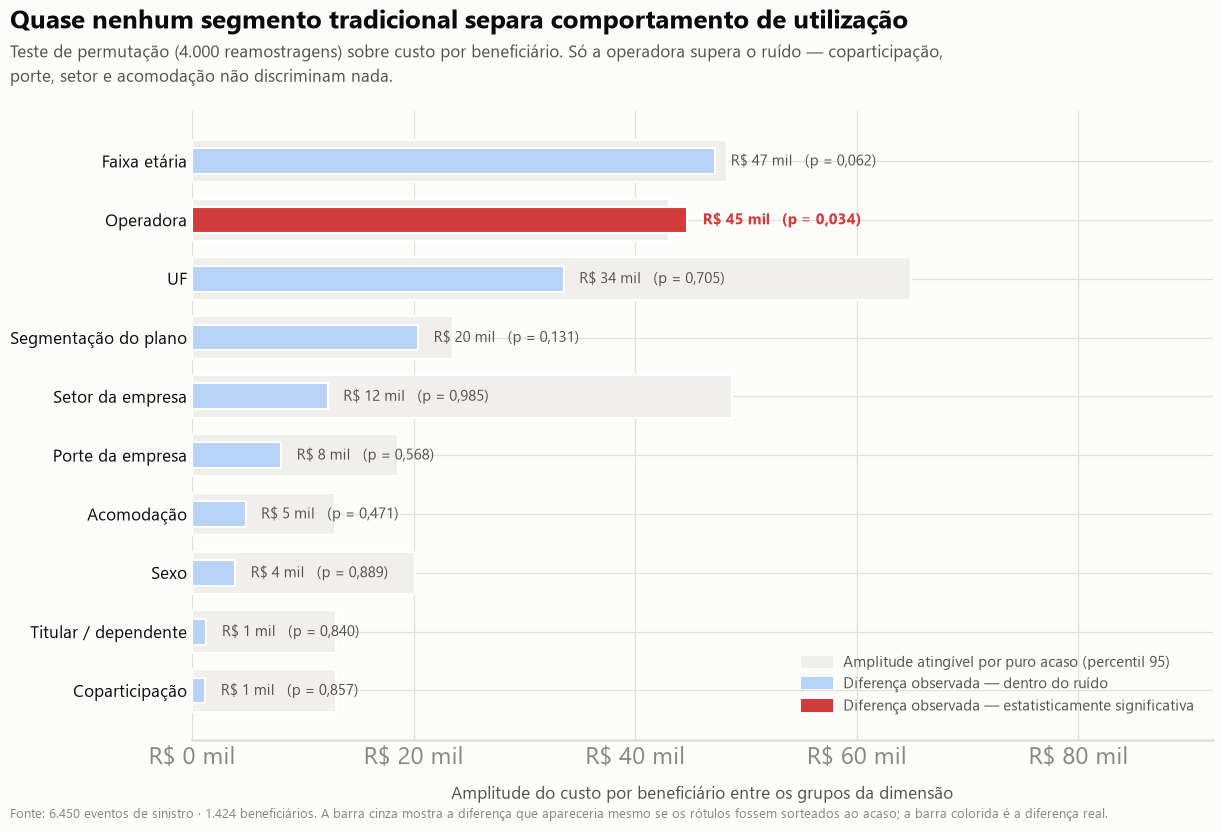

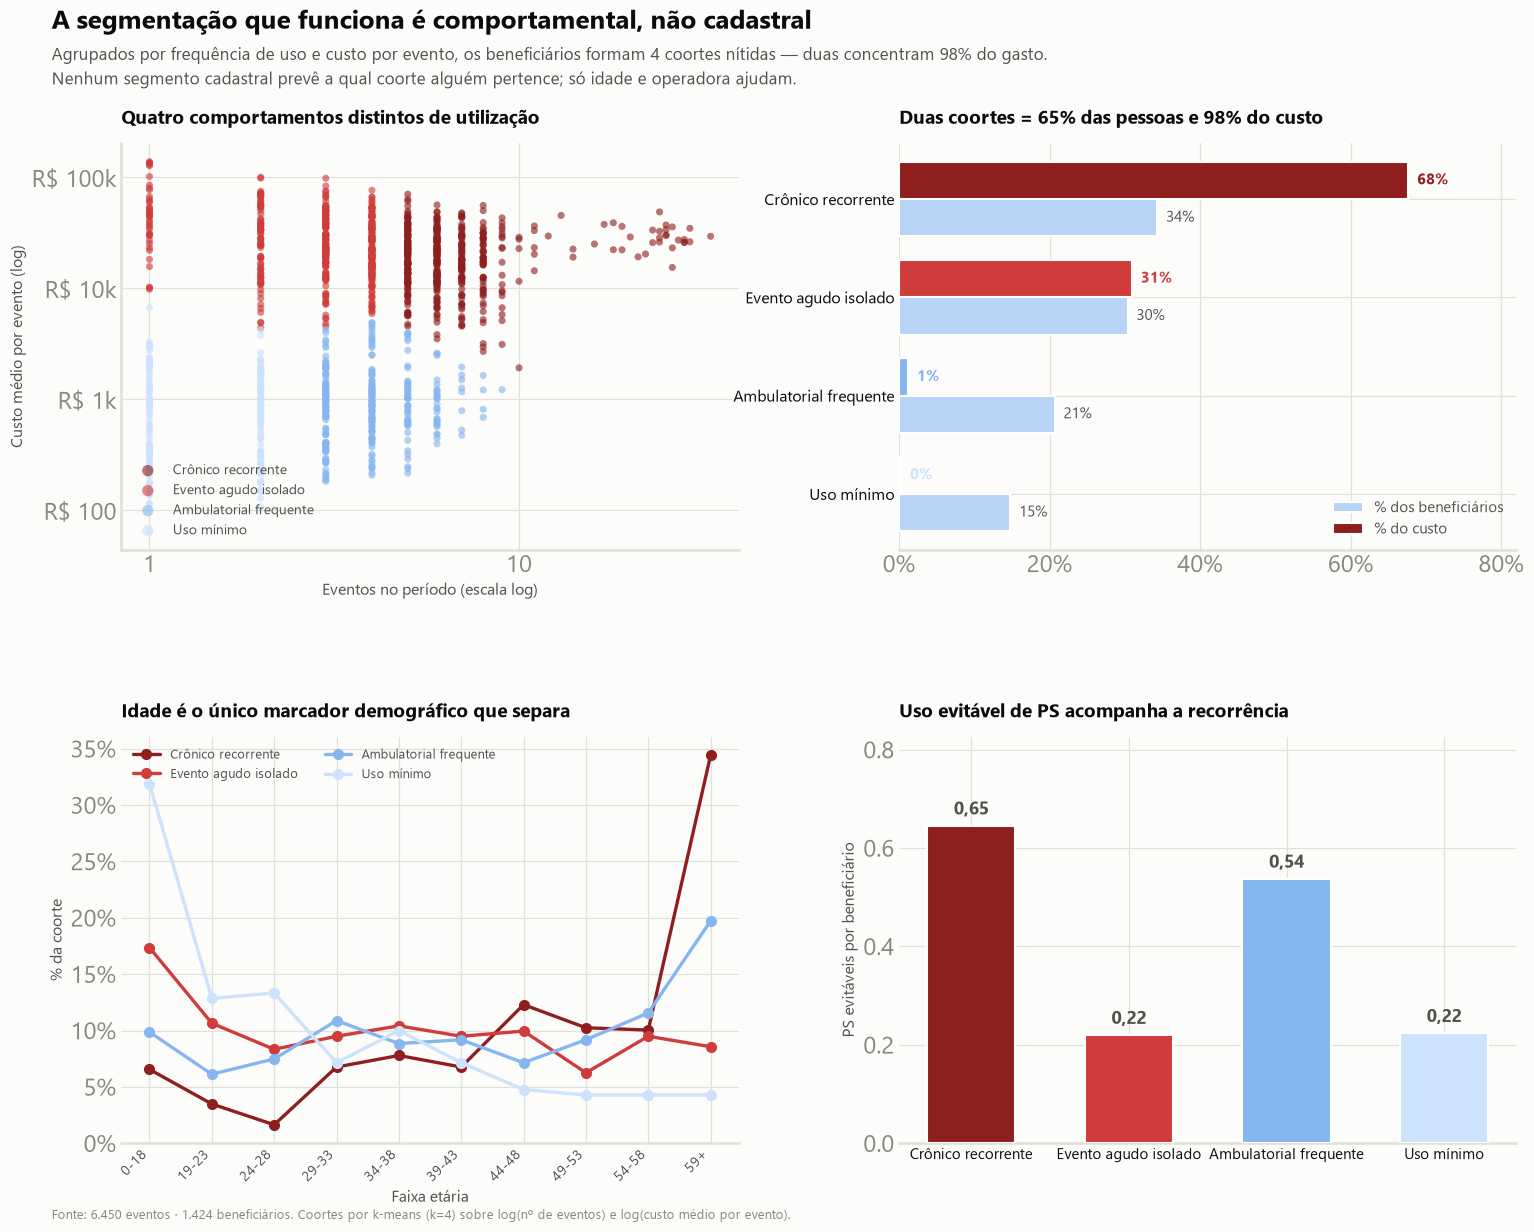

In [86]:

# ----------------------------------------------------------------------------
# Dados
# ----------------------------------------------------------------------------

raw = deep_dive_1.copy()
for col in ["valor_sinistro", "idade", "sk_beneficiario", "preco_vida_mes"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce").astype("float64")
df = raw.dropna(subset=["sk_beneficiario"]).copy()

# Tabela por beneficiario -----------------------------------------------------
attr = df.drop_duplicates("sk_beneficiario").set_index("sk_beneficiario")
ben = df.groupby("sk_beneficiario").agg(custo=("valor_sinistro", "sum"),
                                        ev=("valor_sinistro", "count"),
                                        idade=("idade", "first"))
ben["ticket"] = ben["custo"] / ben["ev"]
ben = ben.join(attr[["flag_coparticipacao", "acomodacao", "segmentacao", "porte",
                     "setor", "faixa_etaria", "tipo_beneficiario", "sexo",
                     "uf", "operadora_nome"]])
ben["ps_evit"] = df[df.flag_ps_evitavel].groupby("sk_beneficiario").size().reindex(ben.index).fillna(0)
N = len(ben)

# ----------------------------------------------------------------------------
# Estilo
# ----------------------------------------------------------------------------
C_SIG = "#d03b3b"; C_NULL = "#b7d3f6"; C_ACCENT = "#2a78d6"
INK_PRIMARY = "#0b0b0b"; INK_SECONDARY = "#52514e"; INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"; SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
})

def br(v, dec=1):
    s = f"{v:,.{dec}f}"
    return s.replace(",", "\x00").replace(".", ",").replace("\x00", ".")

def clean(ax, left=False):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRIDLINE, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_visible(left)
    ax.spines["left"].set_color(GRIDLINE)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.tick_params(length=0)

# ============================================================================
# FIGURA A — Os segmentos a priori quase nao discriminam
# ============================================================================
rng = np.random.default_rng(42)

def perm_test(col, reps=4000):
    """Amplitude observada entre grupos vs. amplitude esperada por acaso."""
    sub = ben.dropna(subset=[col])
    obs = sub.groupby(col)["custo"].mean()
    stat = obs.max() - obs.min()
    vals = sub["custo"].values; labs = sub[col].values
    null = np.array([pd.Series(rng.permutation(vals)).groupby(labs).mean().pipe(
        lambda m: m.max() - m.min()) for _ in range(reps)])
    return stat, (null >= stat).mean(), np.percentile(null, 95)

DIMS = [("flag_coparticipacao", "Coparticipação"), ("tipo_beneficiario", "Titular / dependente"),
        ("sexo", "Sexo"), ("acomodacao", "Acomodação"), ("porte", "Porte da empresa"),
        ("setor", "Setor da empresa"), ("segmentacao", "Segmentação do plano"),
        ("uf", "UF"), ("faixa_etaria", "Faixa etária"), ("operadora_nome", "Operadora")]

rows = []
for col, lbl in DIMS:
    s, p, q95 = perm_test(col)
    rows.append(dict(dim=lbl, amp=s, p=p, q95=q95))
tst = pd.DataFrame(rows).sort_values("amp")

fig, ax = plt.subplots(figsize=(13, 8.5))
fig.patch.set_facecolor(SURFACE)
ypos = np.arange(len(tst))
cores = [C_SIG if p < 0.05 else C_NULL for p in tst["p"]]

# banda de ruido: ate onde o acaso chega
ax.barh(ypos, tst["q95"], height=0.72, color="#f0efec", zorder=2)
ax.barh(ypos, tst["amp"], height=0.44, color=cores, zorder=3)

for y, r in zip(ypos, tst.itertuples()):
    ax.text(r.amp + 1400, y, f"R$ {br(r.amp/1000, 0)} mil   (p = {br(r.p, 3)})",
            va="center", fontsize=10.5,
            color=(C_SIG if r.p < 0.05 else INK_SECONDARY),
            fontweight=("bold" if r.p < 0.05 else "normal"))

ax.set_yticks(ypos); ax.set_yticklabels(tst["dim"], fontsize=12)
ax.tick_params(axis="y", colors=INK_PRIMARY)
clean(ax)
ax.set_xlim(0, tst["q95"].max() * 1.42)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v/1000:.0f} mil"))
ax.set_xlabel("Amplitude do custo por beneficiário entre os grupos da dimensão",
              fontsize=12, color=INK_SECONDARY, labelpad=12)

leg = [mpatches.Patch(color="#f0efec", label="Amplitude atingível por puro acaso (percentil 95)"),
       mpatches.Patch(color=C_NULL, label="Diferença observada — dentro do ruído"),
       mpatches.Patch(color=C_SIG, label="Diferença observada — estatisticamente significativa")]
lg = ax.legend(handles=leg, frameon=False, fontsize=10.5, loc="lower right",
               bbox_to_anchor=(0.995, 0.02))
for t in lg.get_texts():
    t.set_color(INK_SECONDARY)

fig.text(0.045, 0.975,
         "Quase nenhum segmento tradicional separa comportamento de utilização",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.045, 0.938,
         "Teste de permutação (4.000 reamostragens) sobre custo por beneficiário. Só a operadora supera o ruído — "
         "coparticipação,\nporte, setor e acomodação não discriminam nada.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top", linespacing=1.5)

fig.text(0.045, 0.02,
         f"Fonte: {br(len(df),0)} eventos de sinistro · {br(N,0)} beneficiários. "
         "A barra cinza mostra a diferença que apareceria mesmo se os rótulos fossem sorteados ao acaso; "
         "a barra colorida é a diferença real.",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.185, right=0.97, top=0.855, bottom=0.115)
# fig.savefig(OUT_A, dpi=200, facecolor=SURFACE)
# plt.close(fig)
# print("saved:", OUT_A)

# ============================================================================
# FIGURA B — Coortes comportamentais (o que de fato segmenta)
# ============================================================================
Z = StandardScaler().fit_transform(np.log1p(ben[["ev", "ticket"]]))
ben["k"] = KMeans(4, random_state=42, n_init=10).fit_predict(Z)

perfil = ben.groupby("k").agg(cu=("custo", "mean"), ev=("ev", "mean"))
nomes = {}
for k, r in perfil.iterrows():
    if r.cu > 150_000:   nomes[k] = "Crônico\nrecorrente"
    elif r.cu > 50_000:  nomes[k] = "Evento agudo\nisolado"
    elif r.ev > 3:       nomes[k] = "Ambulatorial\nfrequente"
    else:                nomes[k] = "Uso\nmínimo"
ben["coorte"] = ben["k"].map(nomes)

CO = ["Crônico\nrecorrente", "Evento agudo\nisolado", "Ambulatorial\nfrequente", "Uso\nmínimo"]
C_CO = {"Crônico\nrecorrente": "#8f1f1f", "Evento agudo\nisolado": "#d03b3b",
        "Ambulatorial\nfrequente": "#86b6ef", "Uso\nmínimo": "#cde2fb"}

res = ben.groupby("coorte").agg(n=("custo", "size"), ev_pc=("ev", "mean"),
                                ticket=("ticket", "mean"), custo_pc=("custo", "mean"),
                                idade=("idade", "mean"), ps=("ps_evit", "mean"))
res["pct_pessoas"] = res["n"] / N * 100
res["pct_custo"] = ben.groupby("coorte")["custo"].sum() / ben["custo"].sum() * 100
res = res.loc[CO]

fig, axes = plt.subplots(2, 2, figsize=(15.5, 12.5))
fig.patch.set_facecolor(SURFACE)
ax1, ax2, ax3, ax4 = axes.ravel()

# --- Painel 1: scatter frequencia x ticket (o espaco comportamental) --------
for co in CO:
    s = ben[ben.coorte == co]
    ax1.scatter(s["ev"], s["ticket"], s=26, color=C_CO[co], alpha=0.62,
                edgecolor="none", zorder=3, label=co.replace("\n", " "))
clean(ax1, left=True)
ax1.set_yscale("log"); ax1.set_xscale("log")
ax1.set_xlabel("Eventos no período (escala log)", fontsize=11.5, color=INK_SECONDARY)
ax1.set_ylabel("Custo médio por evento (log)", fontsize=11.5, color=INK_SECONDARY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v/1000:.0f}k" if v >= 1000 else f"R$ {v:.0f}"))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
lg1 = ax1.legend(frameon=False, fontsize=10, loc="lower left", markerscale=1.6)
for t in lg1.get_texts():
    t.set_color(INK_SECONDARY)
ax1.set_title("Quatro comportamentos distintos de utilização",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 2: pessoas vs custo (a desproporcao) ---------------------------
y = np.arange(len(CO)); h = 0.38
ax2.barh(y + h/2, res["pct_pessoas"], height=h, color=C_NULL, zorder=3, label="% dos beneficiários")
ax2.barh(y - h/2, res["pct_custo"], height=h, color=[C_CO[c] for c in CO], zorder=3, label="% do custo")
for yy, v in zip(y, res["pct_pessoas"]):
    ax2.text(v + 1.2, yy + h/2, f"{v:.0f}%", va="center", fontsize=10.5, color=INK_SECONDARY)
for yy, v, c in zip(y, res["pct_custo"], CO):
    ax2.text(v + 1.2, yy - h/2, f"{v:.0f}%", va="center", fontsize=10.5,
             color=C_CO[c], fontweight="bold")
ax2.set_yticks(y); ax2.set_yticklabels([c.replace("\n", " ") for c in CO], fontsize=11.5)
ax2.tick_params(axis="y", colors=INK_PRIMARY)
ax2.invert_yaxis()
clean(ax2)
ax2.set_xlim(0, 82)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
lg2 = ax2.legend(frameon=False, fontsize=10.5, loc="lower right")
for t in lg2.get_texts():
    t.set_color(INK_SECONDARY)
ax2.set_title("Duas coortes = 65% das pessoas e 98% do custo",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 3: composicao etaria das coortes -------------------------------
ordem_fx = ["0-18", "19-23", "24-28", "29-33", "34-38", "39-43", "44-48", "49-53", "54-58", "59+"]
comp = pd.crosstab(ben["faixa_etaria"], ben["coorte"], normalize="columns") * 100
comp = comp.loc[ordem_fx, CO]
for i, co in enumerate(CO):
    ax3.plot(range(len(ordem_fx)), comp[co], marker="o", markersize=7,
             linewidth=2.4, color=C_CO[co], label=co.replace("\n", " "), zorder=3)
clean(ax3)
ax3.set_xticks(range(len(ordem_fx)))
ax3.set_xticklabels(ordem_fx, fontsize=10, rotation=45, ha="right")
ax3.tick_params(axis="x", colors=INK_SECONDARY)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax3.set_ylabel("% da coorte", fontsize=11.5, color=INK_SECONDARY)
ax3.set_xlabel("Faixa etária", fontsize=11.5, color=INK_SECONDARY)
lg3 = ax3.legend(frameon=False, fontsize=9.5, loc="upper left", ncol=2)
for t in lg3.get_texts():
    t.set_color(INK_SECONDARY)
ax3.set_title("Idade é o único marcador demográfico que separa",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 4: PS evitavel por coorte --------------------------------------
bars = ax4.bar([c.replace("\n", " ") for c in CO], res["ps"],
               color=[C_CO[c] for c in CO], width=0.56, zorder=3)
for bar, v in zip(bars, res["ps"]):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 0.015, br(v, 2),
             ha="center", va="bottom", fontsize=13, fontweight="bold",
             color=INK_SECONDARY)
clean(ax4)
ax4.set_ylim(0, res["ps"].max() * 1.28)
ax4.set_ylabel("PS evitáveis por beneficiário", fontsize=11.5, color=INK_SECONDARY)
ax4.tick_params(axis="x", labelsize=10.5, colors=INK_PRIMARY)
ax4.set_title("Uso evitável de PS acompanha a recorrência",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

fig.text(0.03, 0.982,
         "A segmentação que funciona é comportamental, não cadastral",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.03, 0.955,
         "Agrupados por frequência de uso e custo por evento, os beneficiários formam 4 coortes nítidas — duas concentram 98% do gasto.\n"
         "Nenhum segmento cadastral prevê a qual coorte alguém pertence; só idade e operadora ajudam.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top", linespacing=1.5)

fig.text(0.03, 0.012,
         f"Fonte: {br(len(df),0)} eventos · {br(N,0)} beneficiários. "
         "Coortes por k-means (k=4) sobre log(nº de eventos) e log(custo médio por evento).",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.075, right=0.975, top=0.875, bottom=0.075,
                    hspace=0.46, wspace=0.26)
# fig.savefig(OUT_B, dpi=200, facecolor=SURFACE)
# plt.close(fig)
# print("saved:", OUT_B)

# ---------------------------------------------------------------------------
print("\n=== COORTES ===")
print(res.round(1).to_string())
print("\n=== TESTES a priori ===")
print(tst.round(4).to_string(index=False))
print("\nchi2 (segmento -> coorte):")
for col in ["flag_coparticipacao", "setor", "porte", "faixa_etaria", "operadora_nome"]:
    p = stats.chi2_contingency(pd.crosstab(ben[col], ben["coorte"]))[1]
    print(f"  {col:22s} p={p:.4f}")
print("\nSpearman idade:",
      f"eventos rho={stats.spearmanr(ben.idade, ben.ev, nan_policy='omit')[0]:+.3f}",
      f"| custo rho={stats.spearmanr(ben.idade, ben.custo, nan_policy='omit')[0]:+.3f}")
plt.show()

# Padrões de utilização: que tipos de evento e especialidades puxam o custo? Há sinais de uso evitável (ex.: pronto-socorro para casos que poderiam ser ambulatoriais)


# Padrões de Utilização — O que Puxa o Custo e Sinais de Uso Evitável

**Base:** 6.465 eventos de sinistro · 1.424 beneficiários · **R\$ 121,1 mi** em custo assistencial

---

## Resumo executivo

Três achados, em ordem de importância:

1. **O custo está no tipo de evento, não na especialidade.** Cirurgia e internação são 30% do volume e **96,7% do custo**. As dez especialidades, por outro lado, são estatisticamente indistinguíveis entre si.
2. **O volume de utilização é uniforme por desenho.** Os sete tipos de evento têm entre 13% e 15% dos atendimentos cada. Isso não é padrão de utilização real — é um sinal de dado sintético ou amostrado por cota.
3. **⚠️ A flag `flag_ps_evitavel` não é avaliação clínica.** Ela é **100% determinada pela especialidade** do atendimento. Isso invalida qualquer leitura de "68% dos PS foram evitáveis" como métrica de qualidade assistencial.

---

## 1. Que tipos de evento puxam o custo?

| Tipo de evento | Eventos | % do volume | Custo | % do custo | Ticket médio |
|---|---|---|---|---|---|
| **Cirurgia** | 995 | 15,4% | R\$ 76,9 mi | **63,5%** | **R\$ 77.286** |
| **Internação** | 963 | 14,9% | R\$ 40,2 mi | **33,2%** | R\$ 41.731 |
| Exame de imagem | 983 | 15,2% | R\$ 1,8 mi | 1,5% | R\$ 1.867 |
| Pronto-socorro | 911 | 14,1% | R\$ 1,3 mi | 1,1% | R\$ 1.404 |
| Exame | 862 | 13,3% | R\$ 520 mil | 0,4% | R\$ 603 |
| Consulta | 892 | 13,8% | R\$ 230 mil | 0,2% | R\$ 257 |
| Terapia | 859 | 13,3% | R\$ 193 mil | 0,2% | R\$ 225 |

Agrupando por natureza do evento:

| Grupo | % do volume | % do custo | Ticket médio |
|---|---|---|---|
| **Hospitalar** | 30,3% | **96,7%** | R\$ 59.799 |
| Diagnóstico | 28,5% | 1,9% | R\$ 1.276 |
| Urgência | 14,1% | 1,1% | R\$ 1.404 |
| Eletivo | 27,1% | 0,3% | R\$ 241 |

**A amplitude de ticket é de 340×** entre uma cirurgia (R\$ 77 mil) e uma terapia (R\$ 225). O custo é inteiramente uma função de **quantos eventos hospitalares acontecem** — nenhuma outra alavanca de volume move o resultado de forma perceptível.

> **Implicação prática:** uma redução de 10% em *todas* as consultas, exames, terapias e PS somados economizaria R\$ 222 mil (0,2% do custo). Uma redução de 10% apenas nas cirurgias economizaria R\$ 7,7 mi (6,3%). Programas de contenção que miram volume ambulatorial estão otimizando a variável errada.

---

## 2. Que especialidades puxam o custo?

**Nenhuma.** Esse é o achado, e é incomum o suficiente para merecer destaque:

| Especialidade | % do custo | Ticket médio |
|---|---|---|
| Clínica geral | 11,3% | R\$ 20.947 |
| Oncologia | 10,9% | R\$ 18.586 |
| Ortopedia | 10,6% | R\$ 18.692 |
| Psiquiatria | 10,0% | R\$ 18.453 |
| Dermatologia | 10,0% | R\$ 18.910 |
| Cardiologia | 9,9% | R\$ 19.232 |
| Ginecologia | 9,7% | R\$ 19.118 |
| Endocrinologia | 9,6% | R\$ 18.737 |
| Oftalmologia | 9,4% | R\$ 17.607 |
| Pediatria | 8,6% | R\$ 17.060 |

Toda a carteira cabe numa faixa de **8,6% a 11,3%** — praticamente 10% cada, que é exatamente o esperado se as dez especialidades fossem equivalentes. E o ticket médio varia apenas de R\$ 17,1 mil a R\$ 20,9 mil.

Testei se ao menos *dentro* da cirurgia (onde está o dinheiro) alguma especialidade é mais cara: **Kruskal-Wallis p = 0,197** — não há diferença significativa. O ticket cirúrgico vai de R\$ 67,9 mil (pediatria) a R\$ 84,2 mil (oftalmologia), tudo dentro do ruído.

**Isso contraria fortemente o padrão do mundo real**, onde oncologia e cardiologia costumam dominar o gasto assistencial. Ver a seção de ressalvas.

---

## 3. Há sinais de uso evitável?

### O dado diz que sim — mas a métrica não sustenta a leitura

| Métrica | Valor |
|---|---|
| Atendimentos de pronto-socorro | 911 (14,1% dos eventos) |
| Custo de PS | R\$ 1,28 mi (**1,06%** do custo total) |
| PS marcados como evitáveis | 615 (**67,5% dos PS**) |
| Custo dos PS evitáveis | R\$ 853 mil (**0,70%** do custo total) |
| Ticket PS evitável vs não evitável | R\$ 1.386 vs R\$ 1.441 |

À primeira vista: **dois em cada três atendimentos de pronto-socorro são evitáveis** — um número alarmante que sugeriria falha grave de navegação assistencial.

### ⚠️ Mas a flag é determinística, não clínica

Ao cruzar `flag_ps_evitavel` com `especialidade`, a estrutura aparece:

| Especialidade | PS | % marcado evitável |
|---|---|---|
| Clínica geral, Dermatologia, Endocrinologia, Ginecologia, Oftalmologia, Pediatria, Psiquiatria | 615 | **100%** |
| Cardiologia, Oncologia, Ortopedia | 296 | **0%** |

**Cada especialidade tem um único valor de flag.** Não existe um só caso de dermatologia marcado como não evitável, nem um só de cardiologia marcado como evitável. A flag não avalia o caso — ela **reproduz uma regra fixa de especialidade**.

Consequências:

- **"67,5% dos PS são evitáveis" é uma tautologia**: significa apenas que 67,5% dos atendimentos de PS ocorreram nas sete especialidades que a regra classifica como evitáveis. Não mede comportamento do beneficiário nem adequação clínica.
- **A regra é clinicamente questionável.** Um atendimento de PS em psiquiatria (surto agudo) ou ginecologia (sangramento) não é evitável por definição; um de ortopedia (entorse leve) frequentemente é. A regra está aplicada na direção oposta em vários casos.
- **Não dá para usar essa flag para desenhar intervenção.** Qualquer programa calibrado por ela estaria mirando especialidade, não comportamento.

### O que ainda é possível afirmar

Analisando a **reincidência** — que independe da flag:

| Nº de PS evitáveis no período | Beneficiários |
|---|---|
| 1 | 408 |
| 2 | 81 |
| 3 | 11 |
| 4 | 3 |

**503 de 1.424 beneficiários (35%) tiveram ao menos um; apenas 14 (1%) são reincidentes com 3 ou mais.** Os reincidentes concentram só 7,3% desses atendimentos.

**O uso é disperso, não concentrado.** Isso é relevante mesmo com a ressalva sobre a flag: não existe um pequeno grupo de "frequentadores de PS" que um programa focado poderia endereçar. Se houver problema de navegação, ele é difuso na carteira — o que exige intervenção populacional (canal de triagem, telemedicina, orientação de porta de entrada), não gestão de caso.

Testei também se o uso de PS evitável **antecede internação** (a "cascata" clássica: paciente mal direcionado piora e interna). **Não há correlação** — Spearman rho = 0,038, p = 0,15. Nos dados, esses atendimentos não se convertem em eventos hospitalares.

---

## 4. Conclusão prática

| Pergunta | Resposta |
|---|---|
| Que tipos de evento puxam o custo? | **Cirurgia (63,5%) e internação (33,2%)** — 96,7% juntos. Tudo mais é irrelevante financeiramente. |
| Que especialidades puxam o custo? | **Nenhuma.** As dez são estatisticamente equivalentes (8,6%–11,3%), inclusive dentro da cirurgia (p = 0,197). |
| Há sinais de uso evitável? | **A métrica disponível não permite responder.** A flag é uma regra de especialidade, não uma avaliação. O que se observa é que o uso de PS é **disperso** (35% da carteira com 1 evento, só 1% reincidente) e **não gera cascata** para internação. |

**Recomendações:**

1. **Focar gestão de custo no evento hospitalar** — auditoria de conta cirúrgica, segunda opinião para eletivas, negociação de pacote e direcionamento de rede. É onde estão 97% do dinheiro.
2. **Não investir em contenção de volume ambulatorial** com objetivo financeiro. Zerar 100% de consultas, exames e terapias economizaria 0,8% do custo.
3. **Reconstruir a definição de "PS evitável"** com critério clínico real — CID/queixa de entrada, classificação de risco (Manchester), ou desfecho do atendimento (alta sem procedimento). A regra atual não é utilizável para gestão.

---

## Ressalvas metodológicas

- **A uniformidade dos dados sugere origem sintética.** Três padrões apontam nessa direção: (a) os sete tipos de evento têm volume quase idêntico (13%–15% cada); (b) as dez especialidades têm participação quase idêntica no custo (~10% cada) e tickets equivalentes; (c) a flag de PS evitável é uma função determinística da especialidade. Em dados reais de saúde suplementar, nada disso ocorre — a distribuição de especialidades é fortemente assimétrica e oncologia/cardiologia dominam. **Os métodos e conclusões estruturais valem; os números específicos não devem ser extrapolados para uma carteira real.**
- **Ausência de eixo temporal na análise.** Não avaliei sazonalidade nem tendência ao longo dos 12 meses. Se o interesse for projeção, isso precisa ser adicionado.
- **Não há normalização por tempo de exposição.** Beneficiários com mais tempo de plano acumulam mais eventos, o que afeta as taxas per capita.
- **A ausência de cascata PS → internação** foi testada apenas por correlação de contagens, sem ordenação temporal. Um teste rigoroso exigiria verificar se a internação ocorreu *depois* do PS, dentro de uma janela definida (ex.: 30 dias).

---
*Gráficos: `utilizacao_custo_vs_volume.png` e `utilizacao_ps_evitavel.png` · Script: `plot_utilizacao.py`*


saved: C:\Users\gnose\Downloads\utilizacao_custo_vs_volume.png
saved: C:\Users\gnose\Downloads\utilizacao_ps_evitavel.png

=== TIPO DE EVENTO ===
                  ev       custo   ticket  pct_ev  pct_custo
tipo_evento                                                 
CIRURGIA         995  76899464.0  77285.9    15.4       63.5
INTERNACAO       963  40186567.1  41730.6    14.9       33.2
EXAME DE IMAGEM  983   1835002.4   1866.7    15.2        1.5
PRONTO-SOCORRO   911   1279069.5   1404.0    14.1        1.1
EXAME            862    519705.8    602.9    13.3        0.4
CONSULTA         892    229556.0    257.3    13.8        0.2
TERAPIA          859    193042.7    224.7    13.3        0.2

=== ESPECIALIDADE ===
                 ev       custo  pct_custo
especialidade                             
CLINICA GERAL   651  13636475.6       11.3
ONCOLOGIA       711  13214642.9       10.9
ORTOPEDIA       690  12897533.3       10.6
PSIQUIATRIA     658  12142358.3       10.0
DERMATOLOGIA    641  121

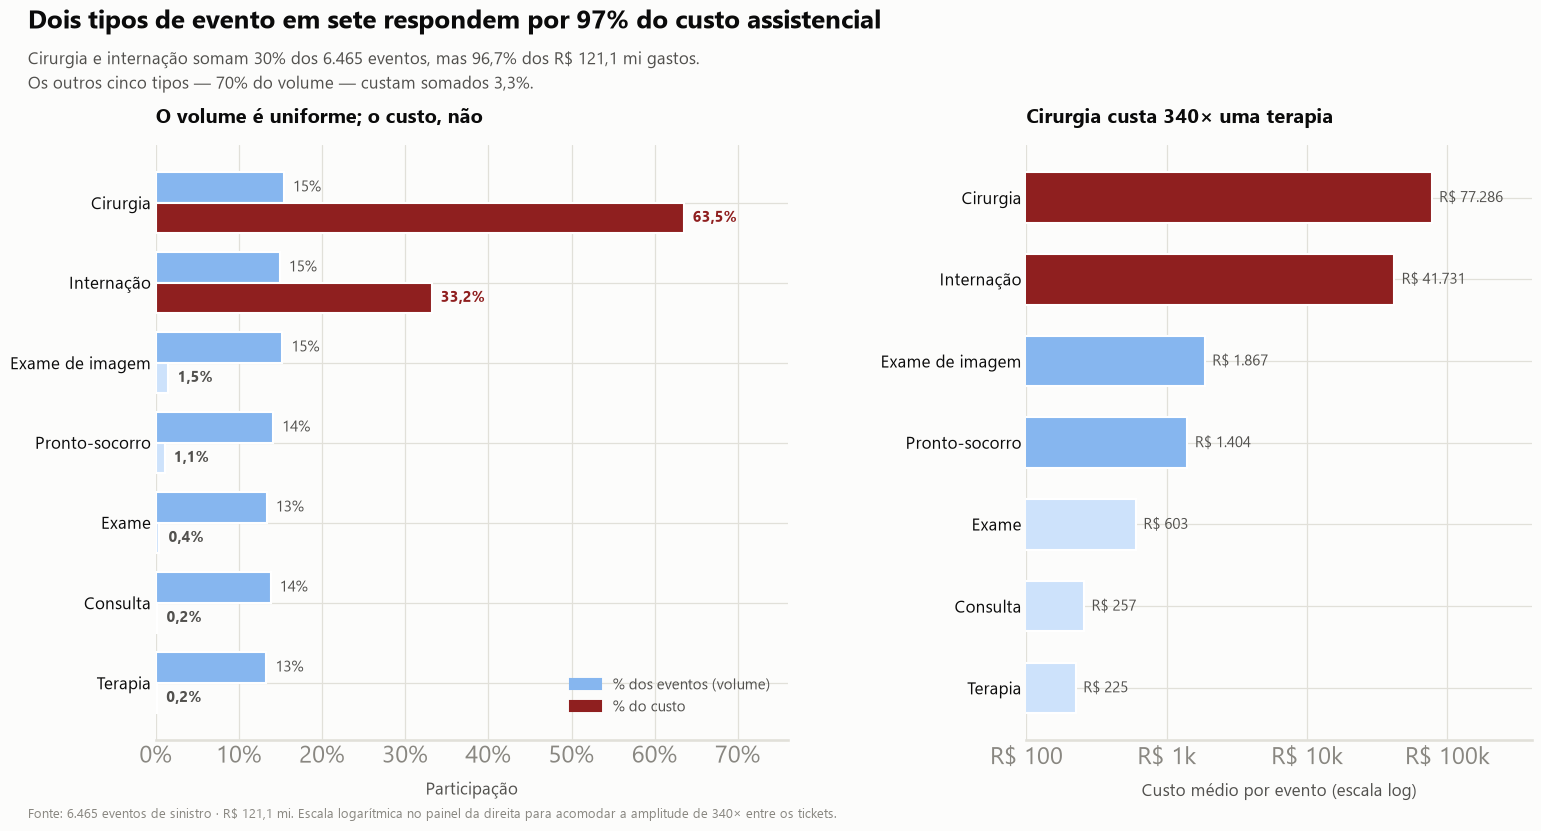

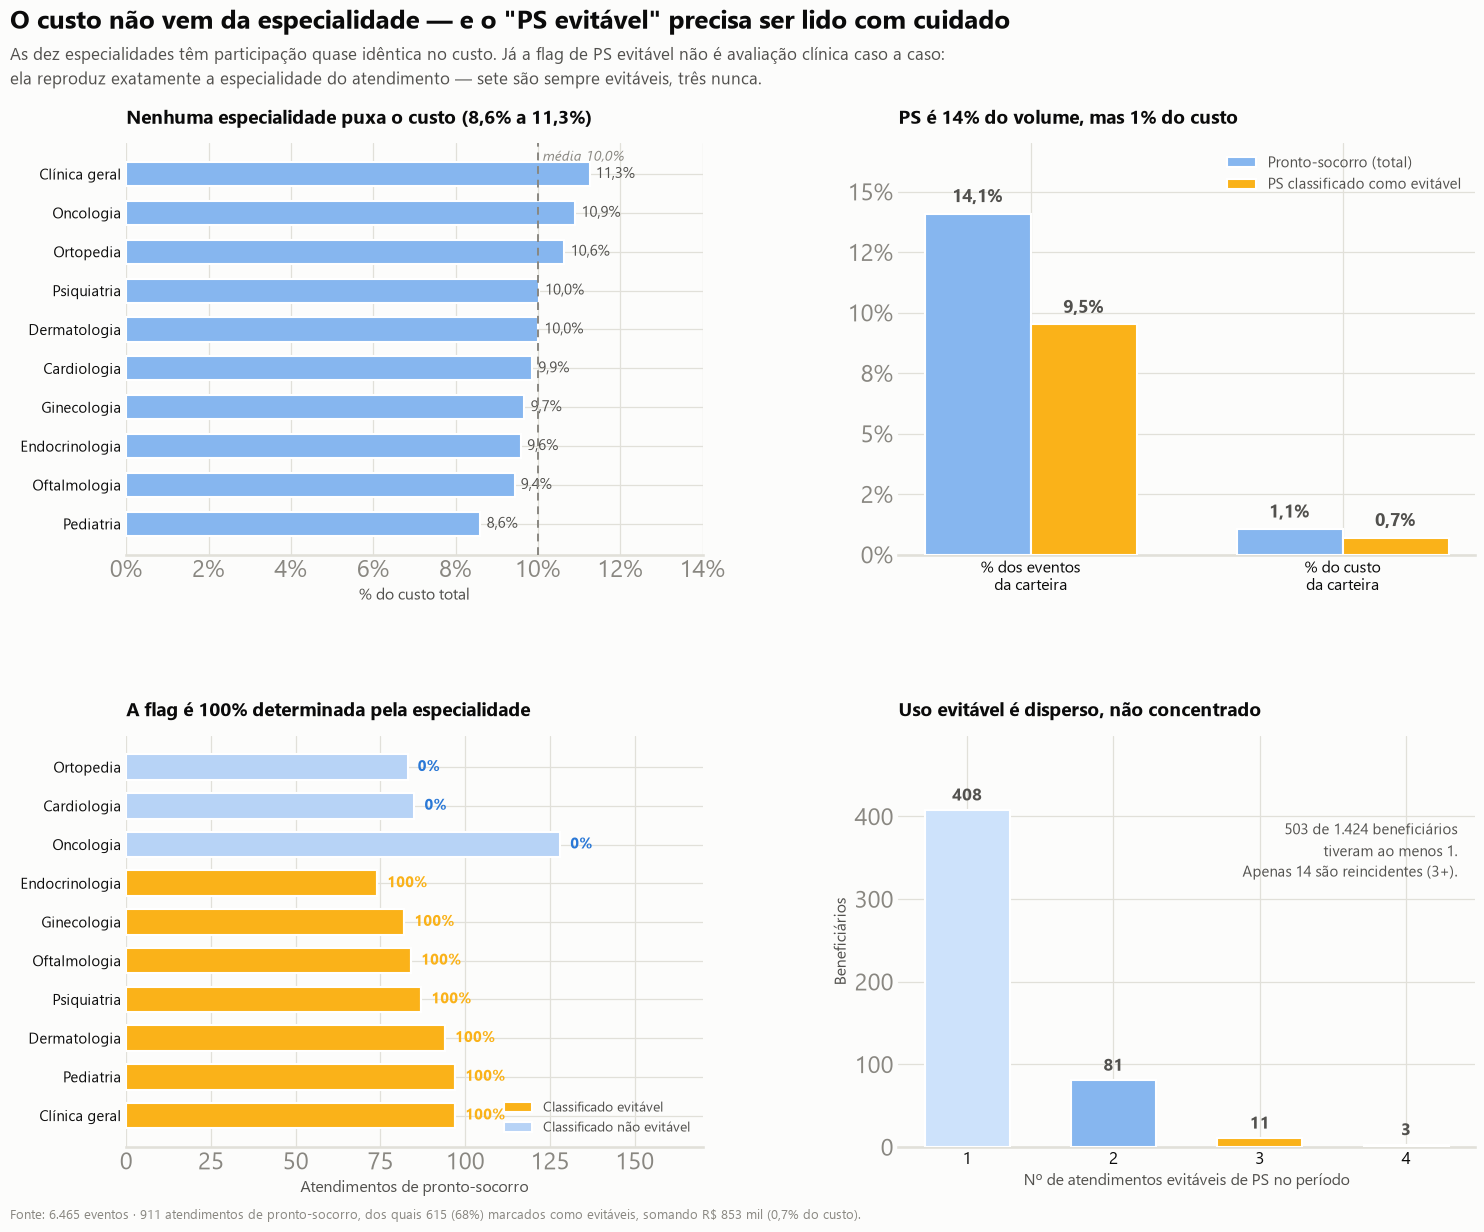

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# ----------------------------------------------------------------------------
# Dados
# ----------------------------------------------------------------------------
SRC = r"C:\Users\gnose\Downloads\5b3a2add-93d6-4590-a6ca-84637eb8100d.csv"
OUT_A = r"C:\Users\gnose\Downloads\utilizacao_custo_vs_volume.png"
OUT_B = r"C:\Users\gnose\Downloads\utilizacao_ps_evitavel.png"

raw = deep_dive_1.copy()
for col in ["valor_sinistro", "idade", "sk_beneficiario"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce").astype("float64")
df = raw.copy()

TOT = df["valor_sinistro"].sum()
NEV = len(df)

# ----------------------------------------------------------------------------
# Estilo
# ----------------------------------------------------------------------------
C_HOSP = "#8f1f1f"; C_ALTO = "#d03b3b"; C_MED = "#fab219"
C_BAIXO = "#86b6ef"; C_MIN = "#cde2fb"; C_ACCENT = "#2a78d6"
INK_PRIMARY = "#0b0b0b"; INK_SECONDARY = "#52514e"; INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"; SURFACE = "#fcfcfb"

sns.set_theme(style="whitegrid", context="talk", font_scale=1.05)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
})

def br(v, dec=1):
    s = f"{v:,.{dec}f}"
    return s.replace(",", "\x00").replace(".", ",").replace("\x00", ".")

def clean(ax, left=False):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRIDLINE, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_visible(left)
    ax.spines["left"].set_color(GRIDLINE)
    ax.spines["bottom"].set_color(GRIDLINE)
    ax.tick_params(length=0)

ROTULO = {
    "CIRURGIA": "Cirurgia", "INTERNACAO": "Internação",
    "EXAME DE IMAGEM": "Exame de imagem", "PRONTO-SOCORRO": "Pronto-socorro",
    "EXAME": "Exame", "CONSULTA": "Consulta", "TERAPIA": "Terapia",
    "CLINICA GERAL": "Clínica geral", "ONCOLOGIA": "Oncologia",
    "ORTOPEDIA": "Ortopedia", "PSIQUIATRIA": "Psiquiatria",
    "DERMATOLOGIA": "Dermatologia", "CARDIOLOGIA": "Cardiologia",
    "GINECOLOGIA": "Ginecologia", "ENDOCRINOLOGIA": "Endocrinologia",
    "OFTALMOLOGIA": "Oftalmologia", "PEDIATRIA": "Pediatria",
}

def titulo_cat(s):
    if s in ROTULO:
        return ROTULO[s]
    p = s.lower().split()
    return " ".join([w if w in ("de", "da", "do") else w.capitalize() for w in p])

# ============================================================================
# FIGURA A — Volume x custo: o descolamento
# ============================================================================
te = df.groupby("tipo_evento").agg(ev=("valor_sinistro", "count"),
                                   custo=("valor_sinistro", "sum"),
                                   ticket=("valor_sinistro", "mean"))
te["pct_ev"] = te["ev"] / NEV * 100
te["pct_custo"] = te["custo"] / TOT * 100
te = te.sort_values("pct_custo", ascending=True)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 8.5),
                               gridspec_kw={"width_ratios": [1.25, 1]})
fig.patch.set_facecolor(SURFACE)

# --- Painel esquerdo: barras espelhadas volume vs custo --------------------
y = np.arange(len(te)); h = 0.38
cores = [C_HOSP if p > 30 else (C_ALTO if p > 10 else C_MIN) for p in te["pct_custo"]]
axA.barh(y + h/2, te["pct_ev"], height=h, color=C_BAIXO, zorder=3)
axA.barh(y - h/2, te["pct_custo"], height=h, color=cores, zorder=3)
for yy, v in zip(y, te["pct_ev"]):
    axA.text(v + 1.1, yy + h/2, f"{v:.0f}%", va="center", fontsize=10.5, color=INK_SECONDARY)
for yy, v, c in zip(y, te["pct_custo"], cores):
    axA.text(v + 1.1, yy - h/2, f"{br(v)}%", va="center", fontsize=10.5,
             color=c if v > 10 else INK_SECONDARY, fontweight="bold")
axA.set_yticks(y)
axA.set_yticklabels([titulo_cat(t) for t in te.index], fontsize=12)
axA.tick_params(axis="y", colors=INK_PRIMARY)
clean(axA)
axA.set_xlim(0, 76)
axA.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
axA.set_xlabel("Participação", fontsize=12, color=INK_SECONDARY, labelpad=10)
handA = [mpatches.Patch(color=C_BAIXO, label="% dos eventos (volume)"),
         mpatches.Patch(color=C_HOSP, label="% do custo")]
lgA = axA.legend(handles=handA, frameon=False, fontsize=11, loc="lower right",
                 bbox_to_anchor=(0.995, 0.02))
for t in lgA.get_texts():
    t.set_color(INK_SECONDARY)
axA.set_title("O volume é uniforme; o custo, não",
              fontsize=14.5, fontweight="bold", color=INK_PRIMARY, pad=16, loc="left")

# --- Painel direito: ticket medio (escala log) ----------------------------
tk = te.sort_values("ticket", ascending=True)
cores2 = [C_HOSP if v > 40000 else (C_BAIXO if v > 1000 else C_MIN) for v in tk["ticket"]]
bars = axB.barh(np.arange(len(tk)), tk["ticket"], color=cores2, height=0.62, zorder=3)
for yy, v in zip(np.arange(len(tk)), tk["ticket"]):
    axB.text(v * 1.13, yy, f"R$ {br(v, 0)}", va="center", fontsize=10.5,
             color=INK_SECONDARY)
axB.set_yticks(np.arange(len(tk)))
axB.set_yticklabels([titulo_cat(t) for t in tk.index], fontsize=12)
axB.tick_params(axis="y", colors=INK_PRIMARY)
clean(axB)
axB.set_xscale("log")
axB.set_xlim(100, 400000)
axB.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"R$ {v/1000:.0f}k" if v >= 1000 else f"R$ {v:.0f}"))
axB.set_xlabel("Custo médio por evento (escala log)", fontsize=12,
               color=INK_SECONDARY, labelpad=10)
axB.set_title("Cirurgia custa 340× uma terapia",
              fontsize=14.5, fontweight="bold", color=INK_PRIMARY, pad=16, loc="left")

fig.text(0.035, 0.975,
         "Dois tipos de evento em sete respondem por 97% do custo assistencial",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.035, 0.930,
         f"Cirurgia e internação somam 30% dos {br(NEV,0)} eventos, mas 96,7% dos R$ {br(TOT/1e6)} mi gastos.\n"
         "Os outros cinco tipos — 70% do volume — custam somados 3,3%.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top", linespacing=1.5)

fig.text(0.035, 0.02,
         f"Fonte: {br(NEV,0)} eventos de sinistro · R$ {br(TOT/1e6)} mi. "
         "Escala logarítmica no painel da direita para acomodar a amplitude de 340× entre os tickets.",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.115, right=0.975, top=0.815, bottom=0.115, wspace=0.42)
fig.savefig(OUT_A, dpi=200, facecolor=SURFACE)
# plt.close(fig)
print("saved:", OUT_A)

# ============================================================================
# FIGURA B — Especialidade e uso evitável de PS
# ============================================================================
esp = df.groupby("especialidade").agg(ev=("valor_sinistro", "count"),
                                      custo=("valor_sinistro", "sum"))
esp["pct_custo"] = esp["custo"] / TOT * 100
esp = esp.sort_values("pct_custo", ascending=True)

ps = df[df.tipo_evento == "PRONTO-SOCORRO"]
n_ps, n_evit = len(ps), int(ps["flag_ps_evitavel"].sum())
custo_evit = ps.loc[ps.flag_ps_evitavel, "valor_sinistro"].sum()

fig, axes = plt.subplots(2, 2, figsize=(15.5, 12.5))
fig.patch.set_facecolor(SURFACE)
ax1, ax2, ax3, ax4 = axes.ravel()

# --- Painel 1: especialidades — todas iguais -------------------------------
ax1.barh(np.arange(len(esp)), esp["pct_custo"], color=C_BAIXO, height=0.62, zorder=3)
media = esp["pct_custo"].mean()
ax1.axvline(media, color=INK_MUTED, linewidth=1.4, linestyle=(0, (4, 3)), zorder=4)
ax1.text(media + 0.12, len(esp) - 0.4, f"média {br(media)}%", fontsize=10,
         color=INK_MUTED, ha="left", va="top", style="italic")
for yy, v in zip(np.arange(len(esp)), esp["pct_custo"]):
    ax1.text(v + 0.15, yy, f"{br(v)}%", va="center", fontsize=10.5, color=INK_SECONDARY)
ax1.set_yticks(np.arange(len(esp)))
ax1.set_yticklabels([titulo_cat(s) for s in esp.index], fontsize=11)
ax1.tick_params(axis="y", colors=INK_PRIMARY)
clean(ax1)
ax1.set_xlim(0, 14)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax1.set_xlabel("% do custo total", fontsize=11.5, color=INK_SECONDARY)
ax1.set_title("Nenhuma especialidade puxa o custo (8,6% a 11,3%)",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 2: PS — volume vs custo (o paradoxo) --------------------------
cats = ["% dos eventos\nda carteira", "% do custo\nda carteira"]
vals_ps = [n_ps / NEV * 100, ps["valor_sinistro"].sum() / TOT * 100]
vals_ev = [n_evit / NEV * 100, custo_evit / TOT * 100]
x = np.arange(2); w = 0.34
b1 = ax2.bar(x - w/2, vals_ps, width=w, color=C_BAIXO, zorder=3, label="Pronto-socorro (total)")
b2 = ax2.bar(x + w/2, vals_ev, width=w, color=C_MED, zorder=3, label="PS classificado como evitável")
for bar, v in list(zip(b1, vals_ps)) + list(zip(b2, vals_ev)):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.32, f"{br(v)}%",
             ha="center", va="bottom", fontsize=13, fontweight="bold", color=INK_SECONDARY)
ax2.set_xticks(x); ax2.set_xticklabels(cats, fontsize=11.5)
ax2.tick_params(axis="x", colors=INK_PRIMARY)
clean(ax2)
ax2.set_ylim(0, 17)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
lg2 = ax2.legend(frameon=False, fontsize=10.5, loc="upper right")
for t in lg2.get_texts():
    t.set_color(INK_SECONDARY)
ax2.set_title("PS é 14% do volume, mas 1% do custo",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 3: a flag é determinística pela especialidade -----------------
# Monta a tabela direto, sem crosstab: evita o problema de rotulo booleano
# (numpy.bool_ vs bool nativo) gerar colunas duplicadas.
flag = ps["flag_ps_evitavel"].astype(bool)
ct = pd.DataFrame({
    "evit": ps[flag].groupby("especialidade").size(),
    "nao_evit": ps[~flag].groupby("especialidade").size(),
}).fillna(0).astype(int)
ct["tot"] = ct["evit"] + ct["nao_evit"]
ct = ct.sort_values(["evit", "tot"], ascending=[False, False])
yp = np.arange(len(ct))
ax3.barh(yp, ct["evit"], color=C_MED, height=0.66, zorder=3, label="Classificado evitável")
ax3.barh(yp, ct["nao_evit"], left=ct["evit"], color="#b7d3f6", height=0.66, zorder=3,
         label="Classificado não evitável")
for yy, ev, tt in zip(yp, ct["evit"], ct["tot"]):
    ax3.text(tt + 3, yy, "100%" if ev > 0 else "0%", va="center", fontsize=10.5,
             color=(C_MED if ev > 0 else C_ACCENT), fontweight="bold")
ax3.set_yticks(yp)
ax3.set_yticklabels([titulo_cat(s) for s in ct.index], fontsize=11)
ax3.tick_params(axis="y", colors=INK_PRIMARY)
clean(ax3)
ax3.set_xlim(0, 170)
ax3.set_xlabel("Atendimentos de pronto-socorro", fontsize=11.5, color=INK_SECONDARY)
lg3 = ax3.legend(frameon=False, fontsize=10, loc="lower right")
for t in lg3.get_texts():
    t.set_color(INK_SECONDARY)
ax3.set_title("A flag é 100% determinada pela especialidade",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

# --- Painel 4: reincidência de PS evitável --------------------------------
pe = df[df.flag_ps_evitavel].groupby("sk_beneficiario").size()
dist = pe.value_counts().sort_index()
bars = ax4.bar(dist.index.astype(int).astype(str), dist.values,
               color=[C_MIN, C_BAIXO, C_MED, C_ALTO][:len(dist)], width=0.58, zorder=3)
for bar, v, k in zip(bars, dist.values, dist.index):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 7, f"{v}",
             ha="center", va="bottom", fontsize=12, fontweight="bold", color=INK_SECONDARY)
clean(ax4)
ax4.set_ylim(0, dist.max() * 1.22)
ax4.set_xlabel("Nº de atendimentos evitáveis de PS no período", fontsize=11.5, color=INK_SECONDARY)
ax4.set_ylabel("Beneficiários", fontsize=11.5, color=INK_SECONDARY)
ax4.tick_params(axis="x", labelsize=12, colors=INK_PRIMARY)
n_rec = int((pe >= 3).sum())
ax4.text(0.97, 0.80,
         f"{br(len(pe),0)} de {br(df.sk_beneficiario.nunique(),0)} beneficiários\n"
         f"tiveram ao menos 1.\nApenas {n_rec} são reincidentes (3+).",
         transform=ax4.transAxes, ha="right", va="top", fontsize=10.5,
         color=INK_SECONDARY, linespacing=1.6)
ax4.set_title("Uso evitável é disperso, não concentrado",
              fontsize=14, fontweight="bold", color=INK_PRIMARY, pad=14, loc="left")

fig.text(0.03, 0.982,
         "O custo não vem da especialidade — e o \"PS evitável\" precisa ser lido com cuidado",
         fontsize=19, fontweight="bold", color=INK_PRIMARY, ha="left", va="top")
fig.text(0.03, 0.955,
         "As dez especialidades têm participação quase idêntica no custo. Já a flag de PS evitável não é avaliação clínica caso a caso:\n"
         "ela reproduz exatamente a especialidade do atendimento — sete são sempre evitáveis, três nunca.",
         fontsize=12.5, color=INK_SECONDARY, ha="left", va="top", linespacing=1.5)

fig.text(0.03, 0.012,
         f"Fonte: {br(NEV,0)} eventos · {br(n_ps,0)} atendimentos de pronto-socorro, "
         f"dos quais {br(n_evit,0)} ({br(n_evit/n_ps*100,0)}%) marcados como evitáveis, somando R$ {br(custo_evit/1000,0)} mil "
         f"({br(custo_evit/TOT*100,1)}% do custo).",
         fontsize=9.5, color=INK_MUTED, ha="left", va="bottom")

plt.subplots_adjust(left=0.105, right=0.975, top=0.875, bottom=0.072,
                    hspace=0.44, wspace=0.34)
fig.savefig(OUT_B, dpi=200, facecolor=SURFACE)
# plt.close(fig)
print("saved:", OUT_B)

# ---------------------------------------------------------------------------
print("\n=== TIPO DE EVENTO ===")
print(te.sort_values("pct_custo", ascending=False).round(1).to_string())
print("\n=== ESPECIALIDADE ===")
print(esp.sort_values("pct_custo", ascending=False).round(1).to_string())
print("\nKruskal ticket cirurgia x especialidade: p =",
      round(stats.kruskal(*[g.valor_sinistro.values for _, g in
                            df[df.tipo_evento == "CIRURGIA"].groupby("especialidade")]).pvalue, 4))
print(f"\nPS: {n_ps} atend. ({n_ps/NEV*100:.1f}% dos eventos, "
      f"{ps.valor_sinistro.sum()/TOT*100:.2f}% do custo) | "
      f"evitáveis: {n_evit} ({n_evit/n_ps*100:.1f}% dos PS, {custo_evit/TOT*100:.2f}% do custo)")
